In [1]:
import pandas as pd
import numpy as np


In [2]:
orders = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_orders_dataset.csv")
orders.shape

(99441, 8)

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [7]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [8]:
orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [10]:
orders = orders[
    ~(
        (orders['order_status'] == 'delivered') &
        (orders['order_delivered_customer_date'].isnull())
    )
]

In [11]:
orders_delivered = orders[orders['order_status'] == 'delivered']

In [12]:
orders_delivered.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [13]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [14]:
products = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_products_dataset.csv")
products.shape

(32951, 9)

In [15]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [16]:
products['product_category_name'] = (products['product_category_name'].astype('category'))

In [17]:
products['product_photos_qty'] = (products['product_photos_qty'].astype('Int64'))

In [18]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [19]:
products = products.dropna()

In [20]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [21]:
sellers = pd.read_csv(r'C:\Users\karan\Downloads\archive (2)\olist_sellers_dataset.csv')
sellers.shape

(3095, 4)

In [22]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [23]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [24]:
sellers.duplicated().sum()

np.int64(0)

In [25]:
product_category = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\product_category_name_translation.csv")
product_category.shape

(71, 2)

In [26]:
product_category.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [27]:
product_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [28]:
customers = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_customers_dataset.csv")
customers.shape

(99441, 5)

In [29]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [30]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [31]:
customers['customer_city'].nunique

<bound method IndexOpsMixin.nunique of 0                       franca
1        sao bernardo do campo
2                    sao paulo
3              mogi das cruzes
4                     campinas
                 ...          
99436                sao paulo
99437          taboao da serra
99438                fortaleza
99439                   canoas
99440                    cotia
Name: customer_city, Length: 99441, dtype: object>

In [32]:
geolocation = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_geolocation_dataset.csv")
geolocation.shape

(1000163, 5)

In [33]:
geolocation.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [34]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [35]:
geolocation.duplicated().sum()


np.int64(261831)

In [36]:
geolocation[geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [37]:
geolocation = geolocation.drop_duplicates()

In [38]:
geolocation.duplicated().sum()


np.int64(0)

In [39]:
geolocation.shape

(738332, 5)

In [40]:
order_items = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_order_items_dataset.csv")
order_items.shape

(112650, 7)

In [41]:
order_items.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [42]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [43]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [44]:
order_items.duplicated().sum()

np.int64(0)

In [45]:
order_payment = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_order_payments_dataset.csv")
order_payment.shape

(103886, 5)

In [46]:
order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [47]:
order_payment.duplicated().sum()

np.int64(0)

In [48]:
order_reviews = pd.read_csv(r"C:\Users\karan\Downloads\archive (2)\olist_order_reviews_dataset.csv")

In [49]:
order_reviews.shape

(99224, 7)

In [50]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [51]:
date_cols = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    order_reviews[col] = pd.to_datetime(order_reviews[col])

In [52]:
master = (orders
  .merge(customers, on='customer_id')
  .merge(order_items, on='order_id')
  .merge(products, on='product_id')
  .merge(product_category, on='product_category_name')
  .merge(order_payment, on='order_id')
  .merge(order_reviews, on='order_id')
)

In [53]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58


In [54]:
master.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,shipping_limit_date,price,freight_value,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp
count,115600,115586,114406,113208,115600,115600.000000,115600.00000,115600,115600.000000,115600.000000,...,115600.000000,115600.000000,115600.000000,115600.000000,115600.000000,115600.000000,115600.000000,115600.000000,115600,115600
mean,2017-12-31 04:21:59.705519104,2017-12-31 15:48:01.769228288,2018-01-04 05:39:38.976732160,2018-01-13 17:24:44.618401536,2018-01-24 01:09:13.328719872,35061.895917,1.19455,2018-01-06 19:53:49.442439424,120.601704,20.057085,...,2113.915969,30.307924,16.638244,23.112846,1.093754,2.946185,172.371908,4.034369,2018-01-12 17:43:13.961937664,2018-01-15 21:19:37.163961856
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-20 00:00:00,1003.000000,1.00000,2016-09-19 00:15:34,0.850000,0.000000,...,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,2016-10-15 00:00:00,2016-10-16 03:20:17
25%,2017-09-12 11:07:07.500000,2017-09-12 18:04:35.249999872,2017-09-15 17:34:15,2017-09-25 18:15:06.249999872,2017-10-03 00:00:00,11310.000000,1.00000,2017-09-19 08:24:40.750000128,39.900000,13.080000,...,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.867500,4.000000,2017-09-23 00:00:00,2017-09-26 23:34:04
50%,2018-01-19 02:41:46,2018-01-19 14:48:18,2018-01-23 23:48:09,2018-02-02 01:44:06,2018-02-15 00:00:00,24241.000000,1.00000,2018-01-25 19:28:52,74.900000,16.320000,...,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.040000,5.000000,2018-02-02 00:00:00,2018-02-05 08:44:22
75%,2018-05-04 15:44:55,2018-05-05 00:26:10,2018-05-08 12:57:00,2018-05-15 19:55:53.750000128,2018-05-25 00:00:00,58745.000000,1.00000,2018-05-10 13:50:23.500000,134.900000,21.210000,...,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.445000,5.000000,2018-05-16 00:00:00,2018-05-20 12:40:01
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,99980.000000,21.00000,2020-04-09 22:35:08,6735.000000,409.680000,...,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,29841.436026,0.68595,NaN,182.581332,15.836700,...,3781.830064,16.211116,13.473566,11.754637,0.729877,2.781090,265.831410,1.385586,NaN,NaN


In [55]:
master.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115600 entries, 0 to 115599
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115600 non-null  object        
 1   customer_id                    115600 non-null  object        
 2   order_status                   115600 non-null  object        
 3   order_purchase_timestamp       115600 non-null  datetime64[ns]
 4   order_approved_at              115586 non-null  datetime64[ns]
 5   order_delivered_carrier_date   114406 non-null  datetime64[ns]
 6   order_delivered_customer_date  113208 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115600 non-null  datetime64[ns]
 8   customer_unique_id             115600 non-null  object        
 9   customer_zip_code_prefix       115600 non-null  int64         
 10  customer_city                  115600 non-null  object        
 11  

In [56]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')

In [58]:
numeric_cols = ['price', 'freight_value', 'payment_value']

summary = master[numeric_cols].describe().T
summary['median'] = master[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = master[numeric_cols].skew()
summary


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
price,115600.0,120.601704,182.581332,0.85,39.9000,74.90,134.900,6735.00,74.90,95.0000,7.616853
freight_value,115600.0,20.057085,15.836700,0.00,13.0800,16.32,21.210,409.68,16.32,8.1300,5.560069
payment_value,115600.0,172.371908,265.831410,0.00,60.8675,108.04,189.445,13664.08,108.04,128.5775,14.312069


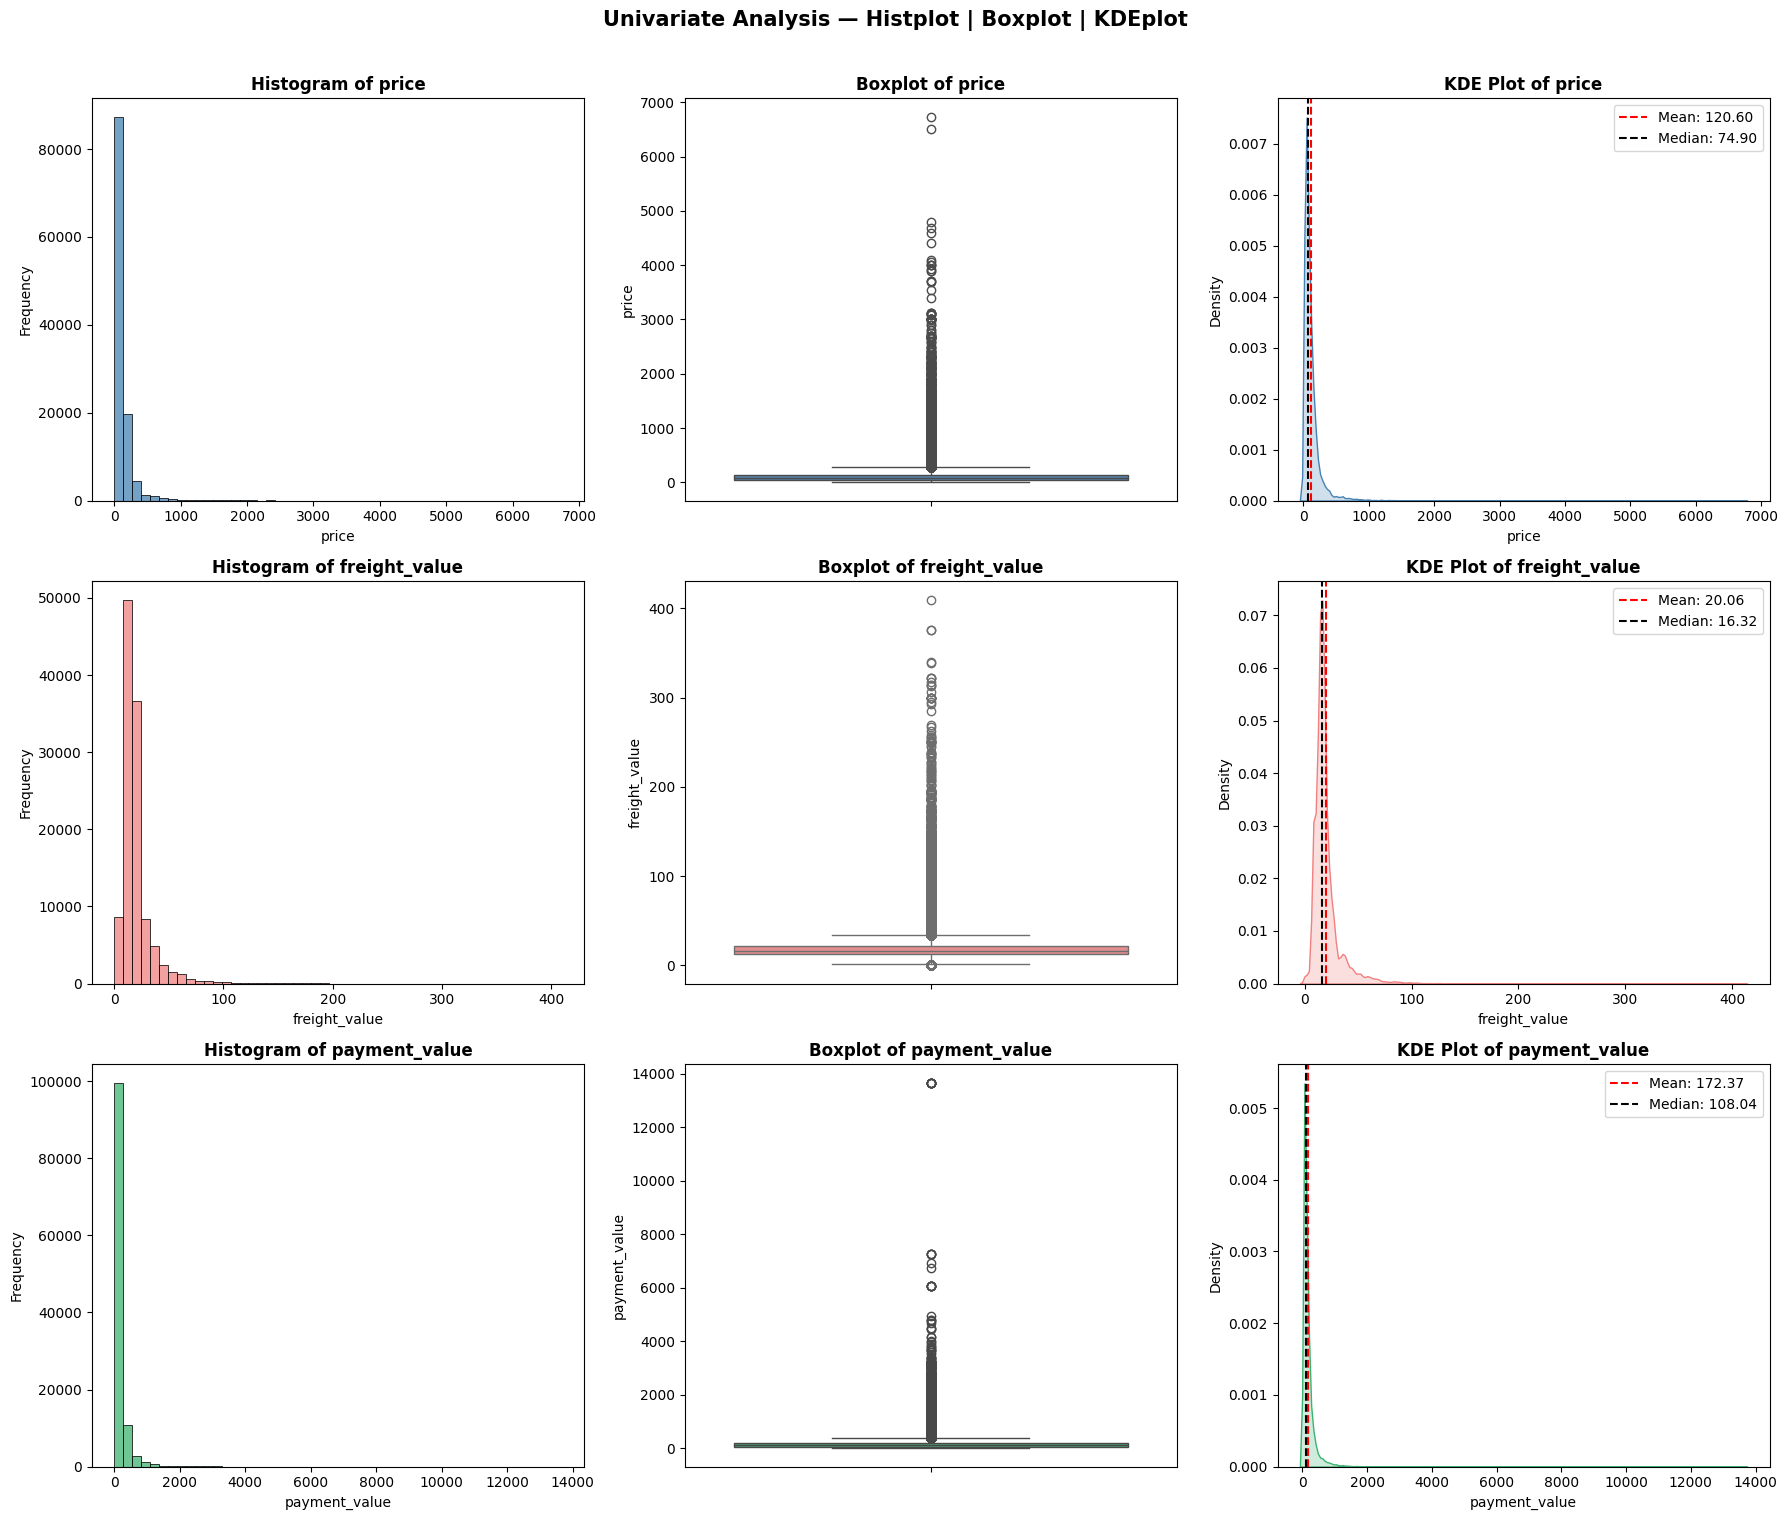

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['price', 'freight_value', 'payment_value']
colors = ['steelblue', 'lightcoral', 'mediumseagreen']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, (col, color) in enumerate(zip(cols, colors)):
    
    # ── Histogram ──────────────────────────────────────────
    sns.histplot(master[col].dropna(), bins=50, ax=axes[i][0], color=color)
    axes[i][0].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frequency')

    # ── Box Plot ───────────────────────────────────────────
    sns.boxplot(y=master[col].dropna(), ax=axes[i][1], color=color)
    axes[i][1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i][1].set_ylabel(col)

    # ── KDE Plot ───────────────────────────────────────────
    sns.kdeplot(master[col].dropna(), ax=axes[i][2], color=color, fill=True)
    axes[i][2].axvline(master[col].mean(),   color='red',   linestyle='--', label=f'Mean: {master[col].mean():.2f}')
    axes[i][2].axvline(master[col].median(), color='black', linestyle='--', label=f'Median: {master[col].median():.2f}')
    axes[i][2].set_title(f'KDE Plot of {col}', fontsize=12, fontweight='bold')
    axes[i][2].set_xlabel(col)
    axes[i][2].legend()

plt.suptitle('Univariate Analysis — Histplot | Boxplot | KDEplot', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


       SKEWNESS BEFORE vs AFTER
price                Before: 7.617  →  After: -0.120
freight_value        Before: 5.560  →  After: -0.777
payment_value        Before: 14.312  →  After: -0.547


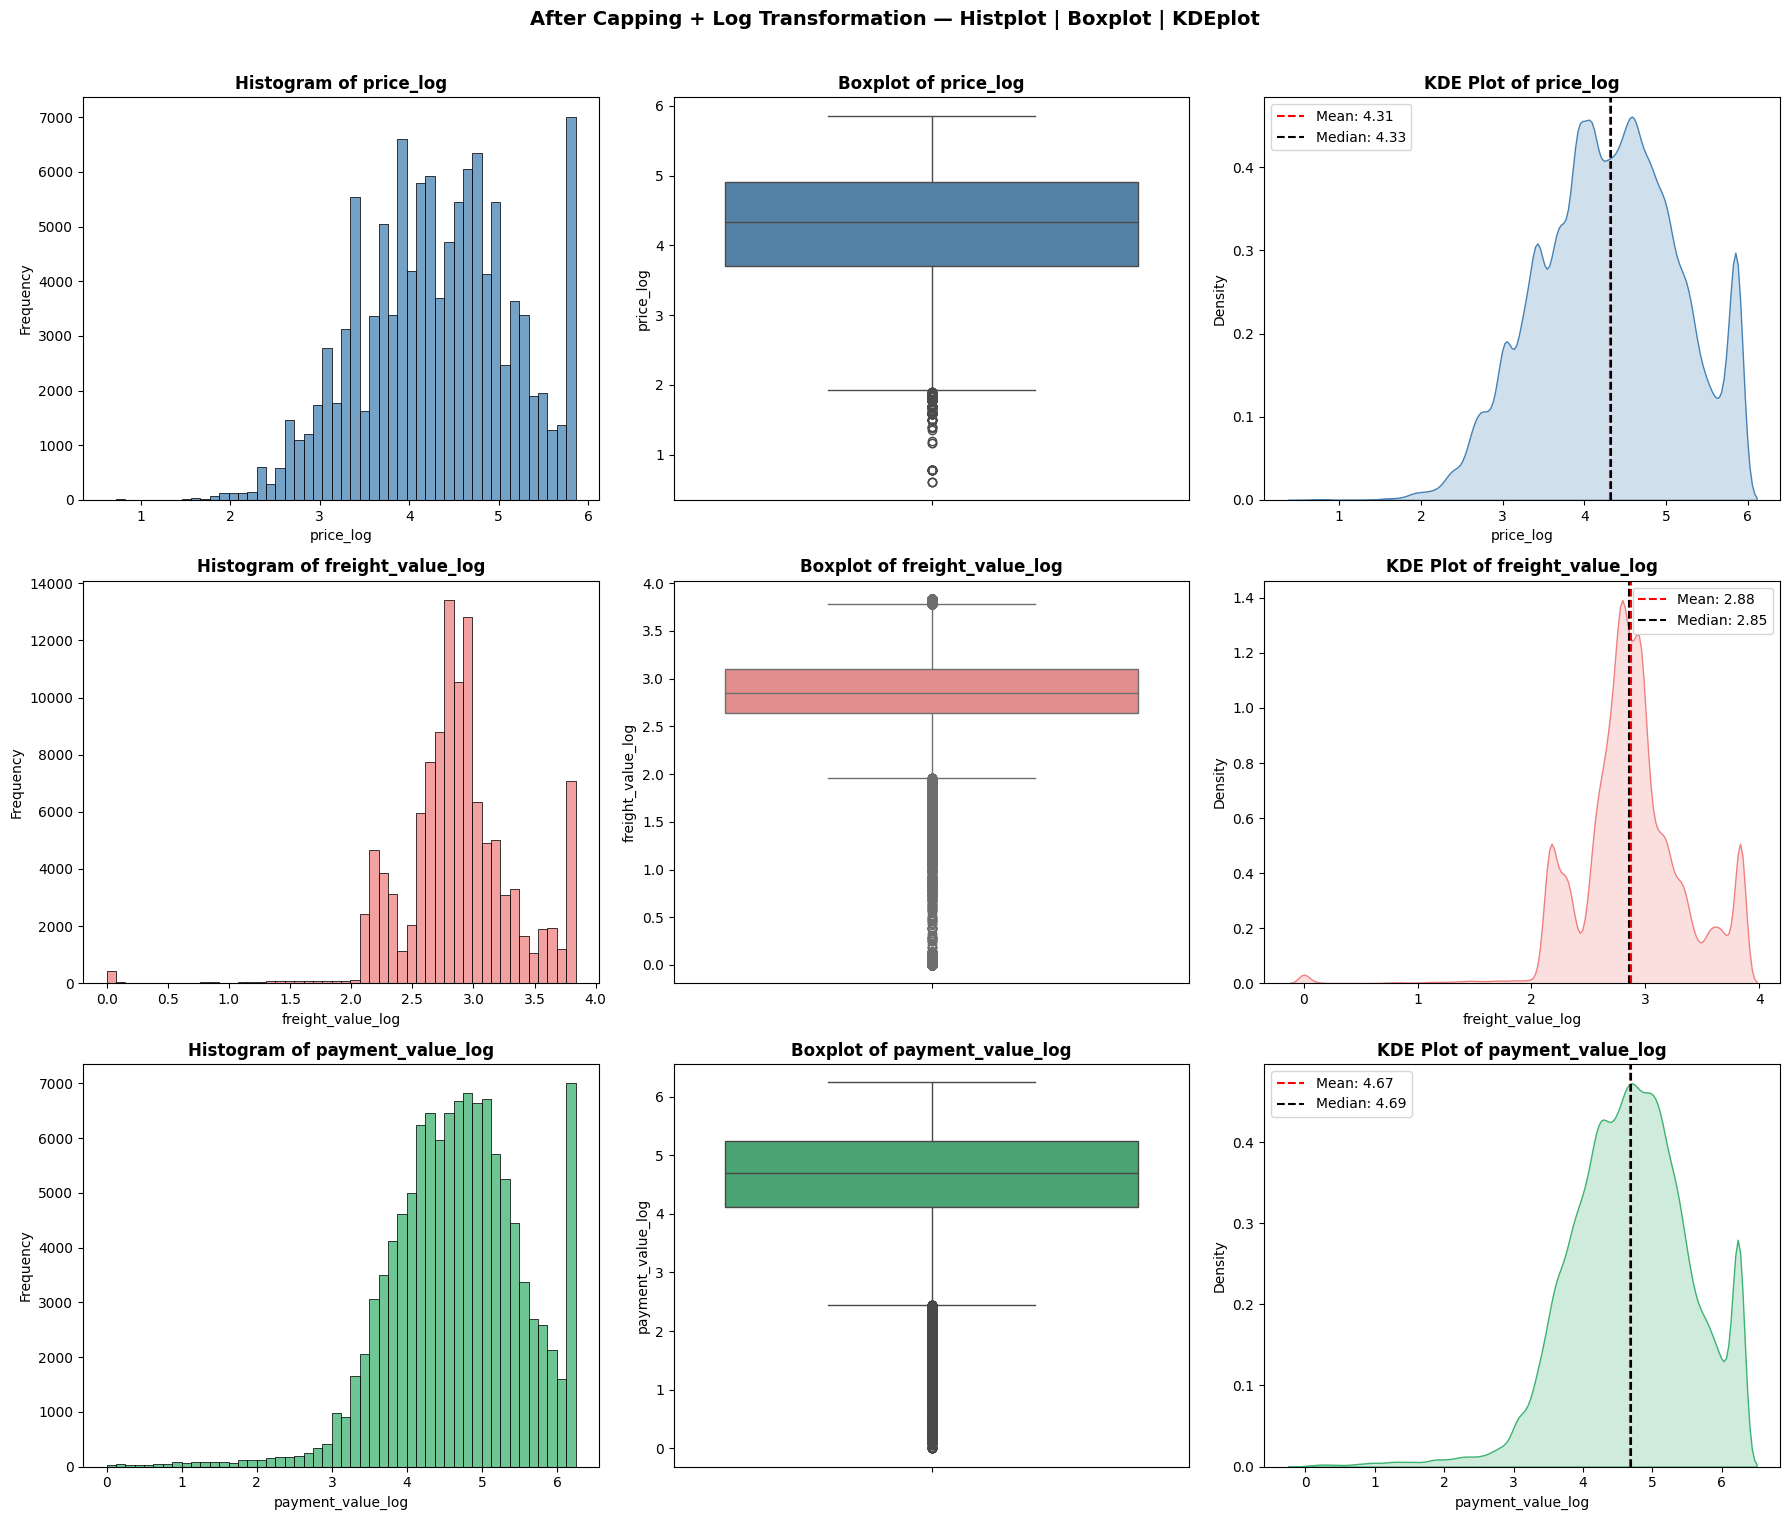

In [64]:
cols = ['price', 'freight_value', 'payment_value']

for col in cols:
    cap_value = master[col].quantile(0.95)
    master[col + '_capped'] = master[col].clip(upper=cap_value)

for col in cols:
    master[col + '_log'] = np.log1p(master[col + '_capped'])

print("\n" + "="*50)
print("       SKEWNESS BEFORE vs AFTER")
print("="*50)
for col in cols:
    before = master[col].skew()
    after  = master[col + '_log'].skew()
    print(f"{col:<20} Before: {before:.3f}  →  After: {after:.3f}")

log_cols = [col + '_log' for col in cols]
colors   = ['steelblue', 'lightcoral', 'mediumseagreen']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, (col, color) in enumerate(zip(log_cols, colors)):

    sns.histplot(master[col].dropna(), bins=50, ax=axes[i][0], color=color)
    axes[i][0].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frequency')

    sns.boxplot(y=master[col].dropna(), ax=axes[i][1], color=color)
    axes[i][1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i][1].set_ylabel(col)

    # KDE Plot
    sns.kdeplot(master[col].dropna(), ax=axes[i][2], color=color, fill=True)
    axes[i][2].axvline(master[col].mean(),   color='red',   linestyle='--', label=f'Mean: {master[col].mean():.2f}')
    axes[i][2].axvline(master[col].median(), color='black', linestyle='--', label=f'Median: {master[col].median():.2f}')
    axes[i][2].set_title(f'KDE Plot of {col}', fontsize=12, fontweight='bold')
    axes[i][2].legend()

plt.suptitle('After Capping + Log Transformation — Histplot | Boxplot | KDEplot',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()




📊 Frequency of order_status
----------------------------------------
order_status
delivered      113201
shipped          1138
canceled          536
invoiced          358
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

📊 Frequency of payment_type
----------------------------------------
payment_type
credit_card    85270
boleto         22510
voucher         6162
debit_card      1658
Name: count, dtype: int64

📊 Frequency of product_category_name_english
----------------------------------------
product_category_name_english
bed_bath_table               11847
health_beauty                 9944
sports_leisure                8941
furniture_decor               8743
computers_accessories         8104
                             ...  
arts_and_craftmanship           24
la_cuisine                      15
cds_dvds_musicals               14
fashion_childrens_clothes        8
security_and_services            2
Name: count, Length: 71, dtype: int64

📊 F

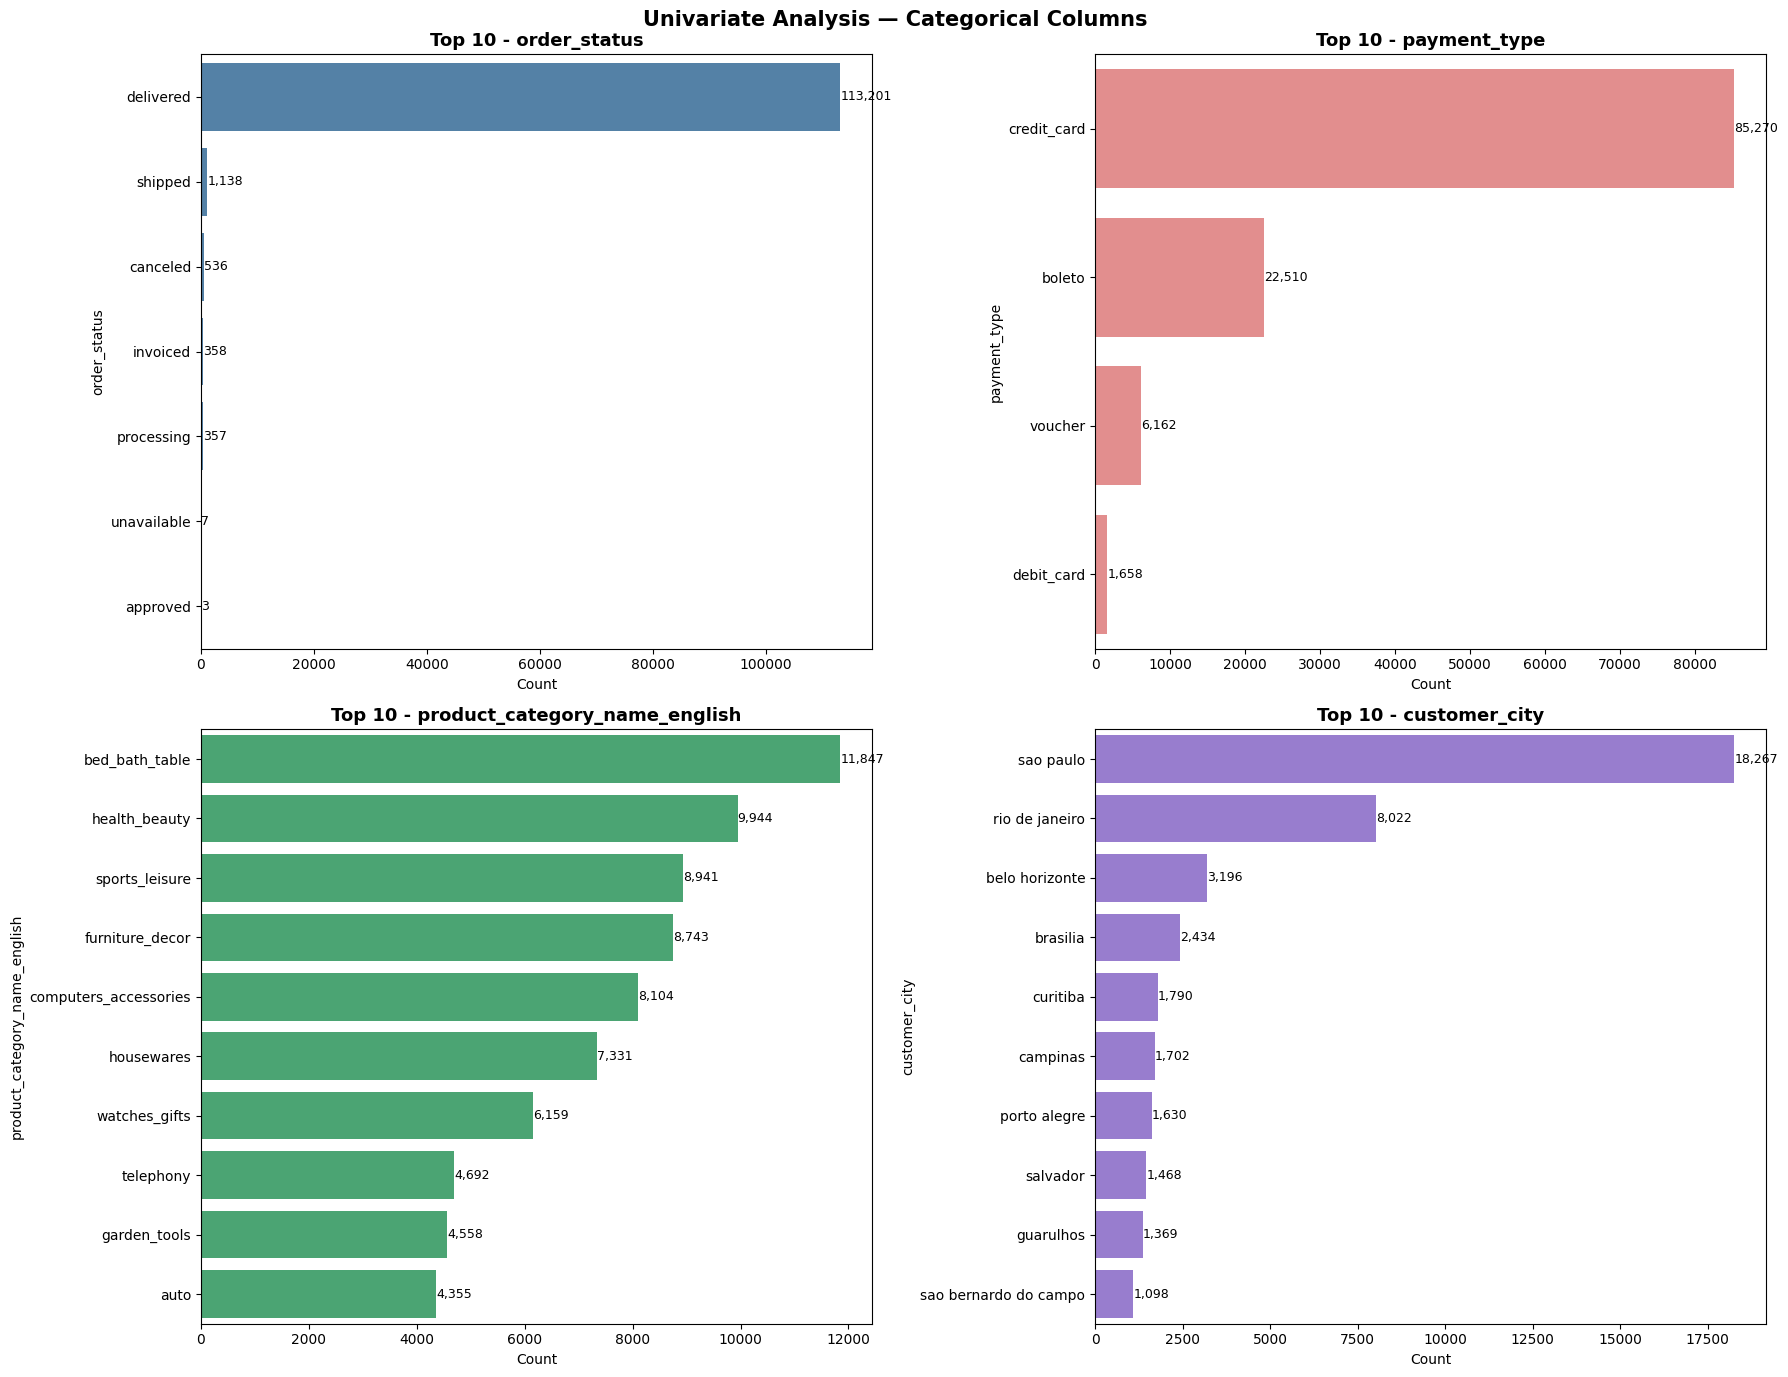

In [ ]:
cols = ['order_status', 'payment_type', 'product_category_name_english', 'customer_city']

print("=" * 60)
for col in cols:
    print(f"\n📊 Frequency of {col}")
    print("-" * 40)
    freq = master[col].value_counts()
    print(freq)
    print("=" * 60)


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

colors = ['steelblue', 'lightcoral', 'mediumseagreen', 'mediumpurple']

for i, (col, color) in enumerate(zip(cols, colors)):

    freq = master[col].value_counts().head(10)

    sns.barplot(x=freq.values, y=freq.index, ax=axes[i], color=color)
    axes[i].set_title(f'Top 10 - {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_width()):,}',
                         (p.get_width(), p.get_y() + p.get_height() / 2),
                         ha='left', va='center', fontsize=9, color='black')

plt.suptitle('Univariate Analysis — Categorical Columns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

          DATE RANGE CHECK

📅 order_purchase_timestamp
   Start : 2016-09-04 21:15:19
   End   : 2018-09-03 09:06:57
   Range : 728 days

📅 order_delivered_customer_date
   Start : 2016-10-11 13:46:32
   End   : 2018-10-17 13:22:46
   Range : 735 days

📅 order_estimated_delivery_date
   Start : 2016-10-20 00:00:00
   End   : 2018-10-25 00:00:00
   Range : 735 days


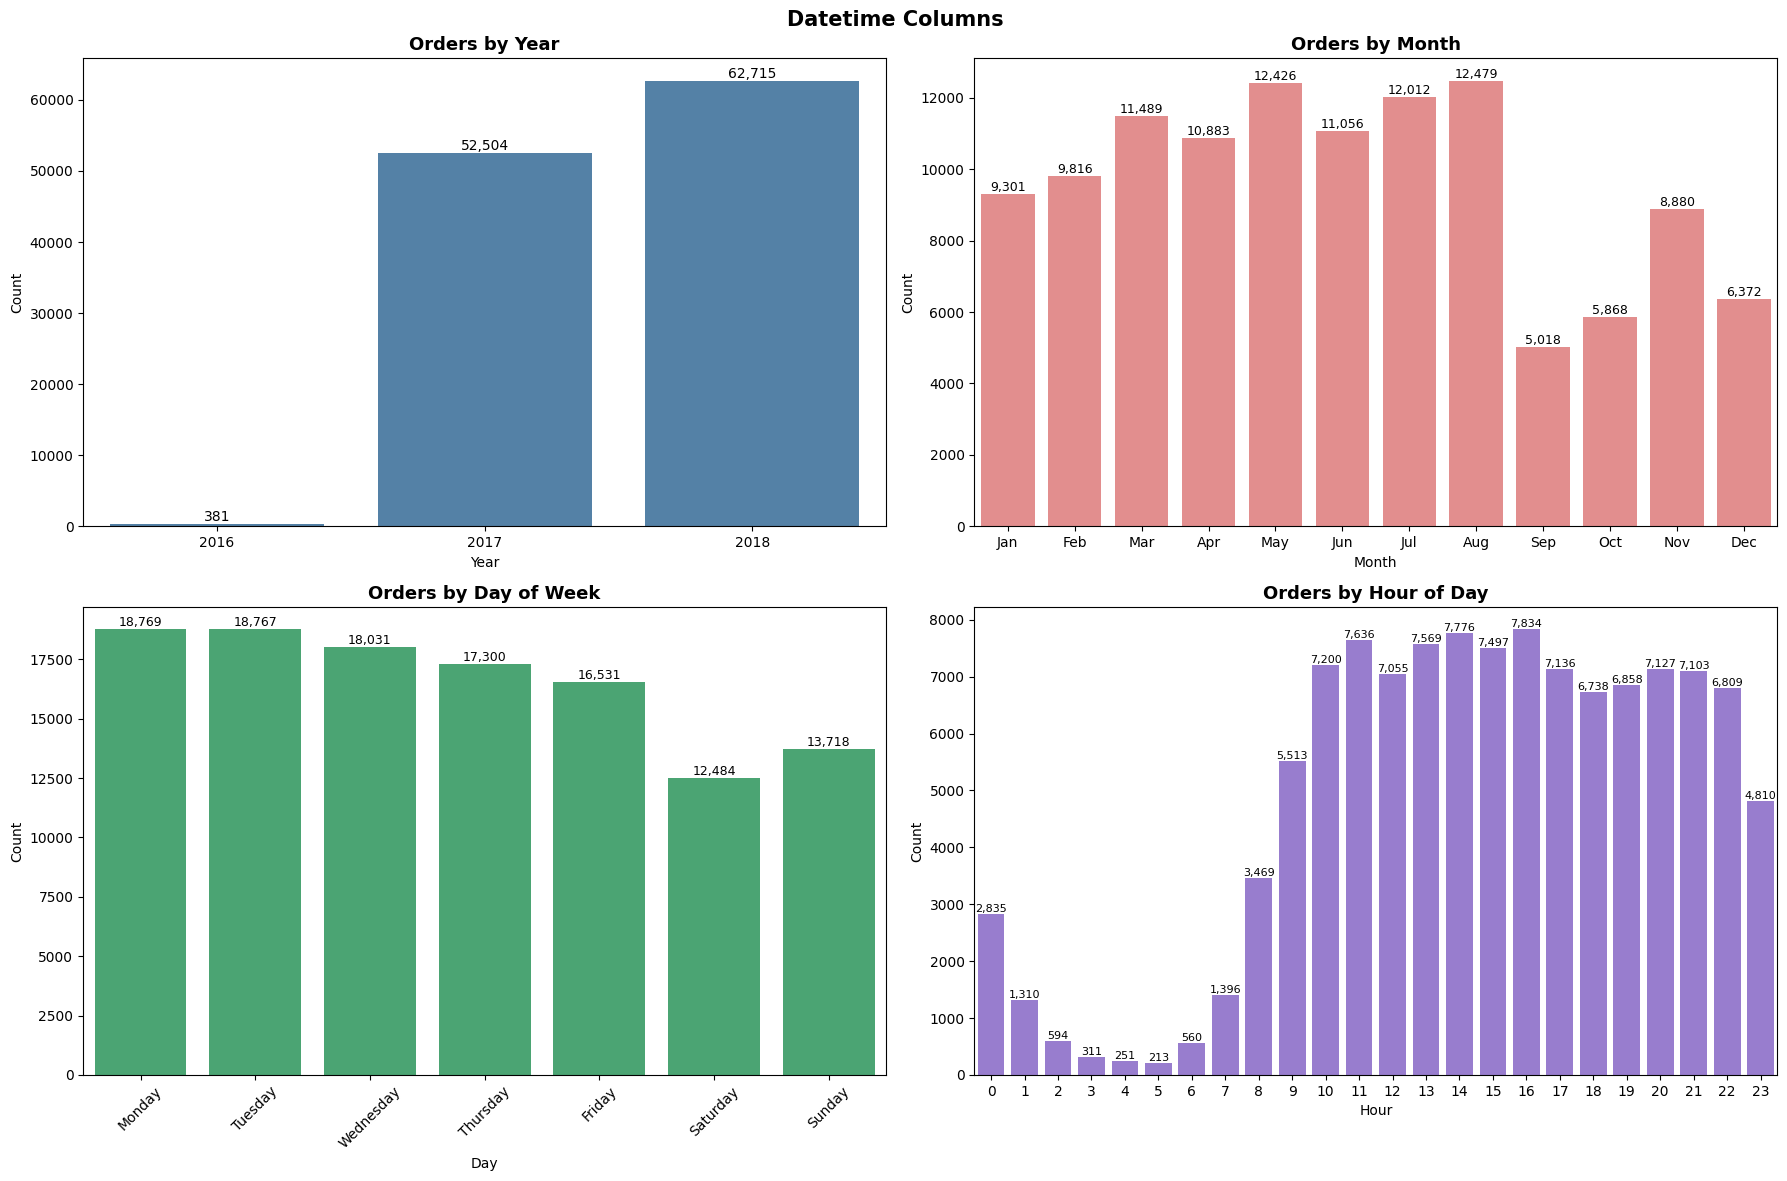

In [68]:
print("=" * 60)
print("          DATE RANGE CHECK")
print("=" * 60)
cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in cols:
    print(f"\n📅 {col}")
    print(f"   Start : {master[col].min()}")
    print(f"   End   : {master[col].max()}")
    print(f"   Range : {(master[col].max() - master[col].min()).days} days")


master['order_year']       = master['order_purchase_timestamp'].dt.year
master['order_month']      = master['order_purchase_timestamp'].dt.month
master['order_day_of_week'] = master['order_purchase_timestamp'].dt.day_name()
master['order_hour']       = master['order_purchase_timestamp'].dt.hour

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

year_freq = master['order_year'].value_counts().sort_index()
sns.barplot(x=year_freq.index, y=year_freq.values, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Orders by Year', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Year')
axes[0][0].set_ylabel('Count')
for p in axes[0][0].patches:
    axes[0][0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10)


month_freq = master['order_month'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.barplot(x=month_names, y=month_freq.values, ax=axes[0][1], color='lightcoral')
axes[0][1].set_title('Orders by Month', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Month')
axes[0][1].set_ylabel('Count')
for p in axes[0][1].patches:
    axes[0][1].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_freq  = master['order_day_of_week'].value_counts().reindex(day_order)
sns.barplot(x=day_freq.index, y=day_freq.values, ax=axes[1][0], color='mediumseagreen')
axes[1][0].set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Day')
axes[1][0].set_ylabel('Count')
axes[1][0].tick_params(axis='x', rotation=45)
for p in axes[1][0].patches:
    axes[1][0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

hour_freq = master['order_hour'].value_counts().sort_index()
sns.barplot(x=hour_freq.index, y=hour_freq.values, ax=axes[1][1], color='mediumpurple')
axes[1][1].set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Hour')
axes[1][1].set_ylabel('Count')
for p in axes[1][1].patches:
    axes[1][1].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.suptitle('Datetime Columns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
master = master[master['order_year'] != 2016]


                   Jan         Feb         Mar         Apr         May  \
order_year                                                               
2017         184100.75   333864.69   512052.08   489106.54   710108.95   
2018        1369762.26  1287157.15  1444774.74  1477364.11  1489965.60   

                   Jun         Jul         Aug         Sep        Oct  \
order_year                                                              
2017         593480.47   730356.79   817918.78  1006604.81  994754.59   
2018        1289913.85  1330587.57  1218501.80      166.46        NaN   

                   Nov         Dec  
order_year                          
2017        1561124.88  1011382.75  
2018               NaN         NaN  


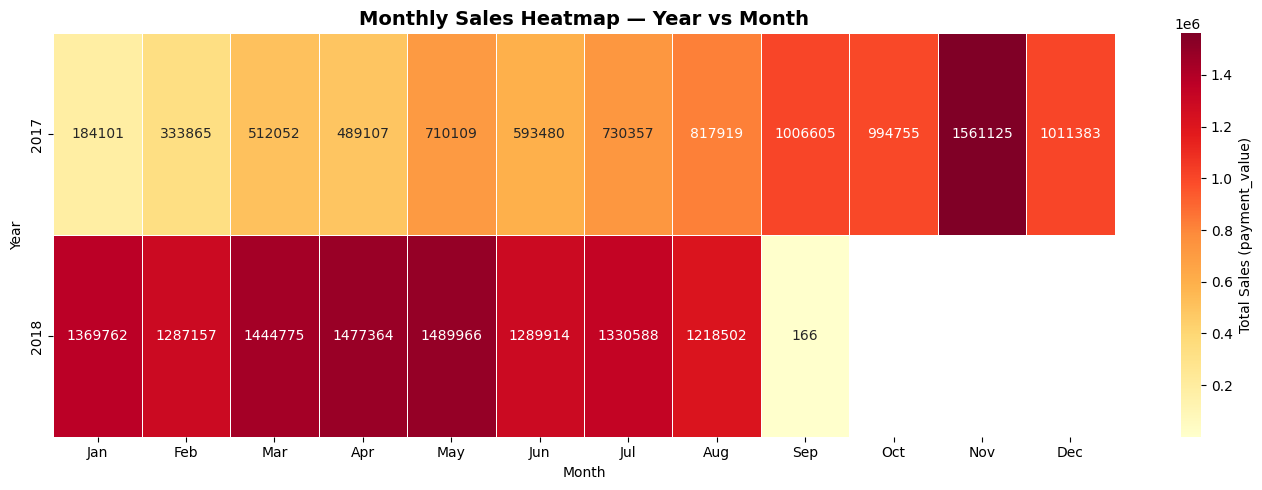

In [71]:

master['order_year']  = master['order_purchase_timestamp'].dt.year
master['order_month'] = master['order_purchase_timestamp'].dt.month

pivot = master.groupby(['order_year', 'order_month'])['payment_value'].sum().unstack()


pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(pivot)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, 
            annot=True,           
            fmt='.0f',            
            cmap='YlOrRd',        
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Total Sales (payment_value)'})

plt.title('Monthly Sales Heatmap — Year vs Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

In [72]:
# Check sample reviews
print(master['review_comment_message'].dropna().head(10).tolist())

['Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.', 'Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.', 'Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.', 'Muito bom o produto.', 'O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.', 'Aguardando retorno da loja', 'Aguardando retorno da loja', 'Gostei do produto', 'Obrigado pela atenção. Lojas lannister perfeito em tudo.', 'os correios estäo em greve... näo recebi nenhum aviso de atraso, mas de qqer forma a empresa responsável deveria dar alguma resposta sobre o atraso.']


   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 608.4/608.4 kB 4.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 3.5 MB/s eta 0:00:04
   -- ------------------------------------- 1.0/14.2 MB 2.7 MB/s eta 0:00:05
   ----- ---------------------------------- 2.1/14.2 MB 3.3 MB/s eta 0:00:04
   -------- ------------------------------- 2.9/14.2 MB 3.7 MB/s eta 0:00:04
   ---------- ----------------------------- 3.7/14.2 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 4.5/14.2 MB 3.6 MB/s eta 0:00:03
   --------------- ------------------------ 5.5/14.2 MB 3.8 MB/s eta 0:00:03
   ------------------ --------------------- 6.6/14.2 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 7.3/14.2 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 8.4/14.2 MB 4.0 MB/s eta 0:00:02
   ------

config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

c:\Users\karan\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\karan\.cache\huggingface\hub\models--pysentimiento--bertweet-pt-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

bpe.codes:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Total reviews to analyze: 5000
sentiment
POS    2212
NEU    1783
NEG    1005
Name: count, dtype: int64


C:\Users\karan\AppData\Local\Temp\ipykernel_27960\2777986425.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\2777986425.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment',


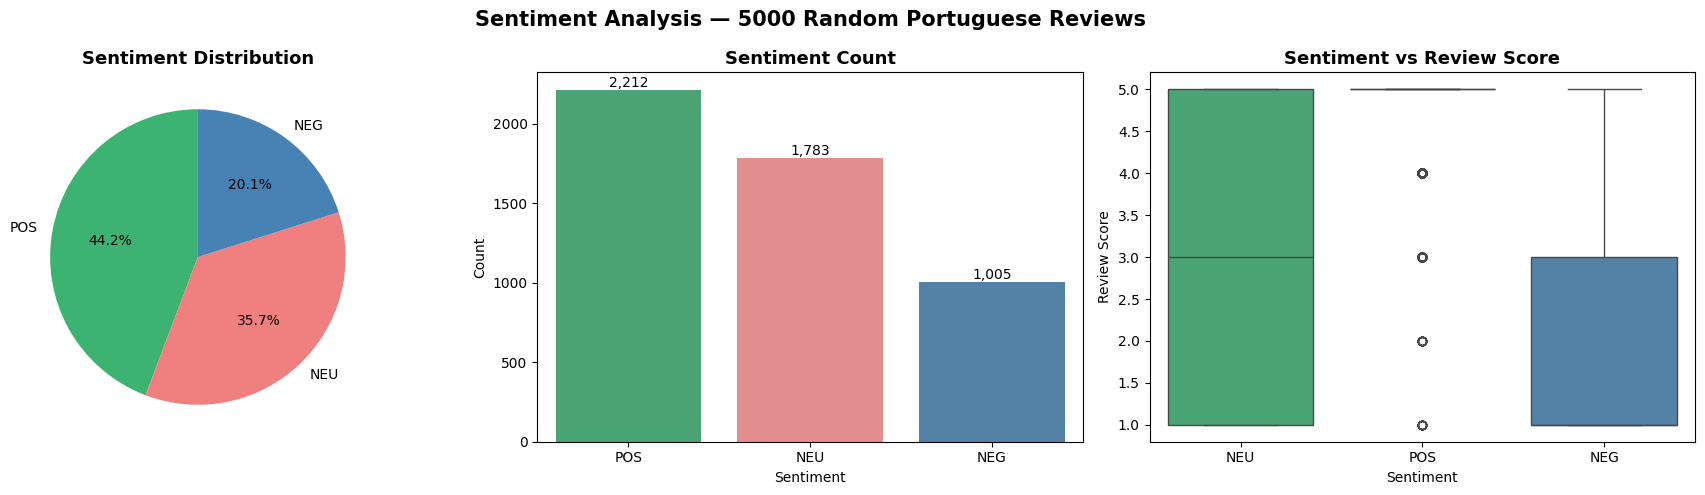

In [ ]:
!pip install pysentimiento

from pysentimiento import create_analyzer

analyzer = create_analyzer(task='sentiment', lang='pt')

reviews_df = master[master['review_comment_message'].notna()].sample(5000, random_state=42).copy()
print(f"Total reviews to analyze: {len(reviews_df)}")

def get_sentiment(text):
    try:
        result = analyzer.predict(text)
        return result.output
    except:
        return 'NEU'

reviews_df['sentiment'] = reviews_df['review_comment_message'].apply(get_sentiment)
print(reviews_df['sentiment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['mediumseagreen', 'lightcoral', 'steelblue']

sentiment_counts = reviews_df['sentiment'].value_counts()
axes[0].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

sns.barplot(x=sentiment_counts.index,
            y=sentiment_counts.values,
            ax=axes[1],
            palette=colors)
axes[1].set_title('Sentiment Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

sns.boxplot(x='sentiment',
            y='review_score',
            data=reviews_df,
            ax=axes[2],
            palette=colors)
axes[2].set_title('Sentiment vs Review Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Review Score')

plt.suptitle('Sentiment Analysis — 5000 Random Portuguese Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

    NEGATIVE REVIEWS BY PRODUCT CATEGORY
product_category_name_english
bed_bath_table           104
computers_accessories     89
health_beauty             81
furniture_decor           79
sports_leisure            69
housewares                59
watches_gifts             53
telephony                 49
garden_tools              46
perfumery                 36
Name: count, dtype: int64


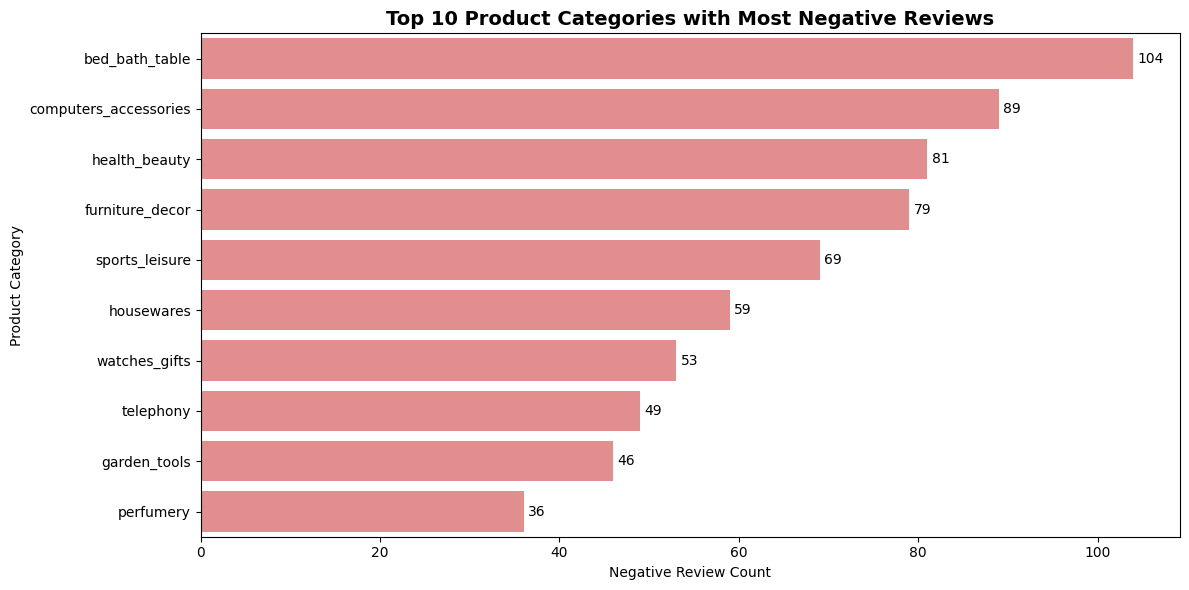

In [75]:
neg_reviews = reviews_df[reviews_df['sentiment'] == 'NEG']

print("=" * 60)
print("    NEGATIVE REVIEWS BY PRODUCT CATEGORY")
print("=" * 60)
neg_cat = neg_reviews['product_category_name_english'].value_counts().head(10)
print(neg_cat)


plt.figure(figsize=(12, 6))
sns.barplot(x=neg_cat.values, y=neg_cat.index, color='lightcoral')
plt.title('Top 10 Product Categories with Most Negative Reviews',
          fontsize=14, fontweight='bold')
plt.xlabel('Negative Review Count')
plt.ylabel('Product Category')

for i, v in enumerate(neg_cat.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()


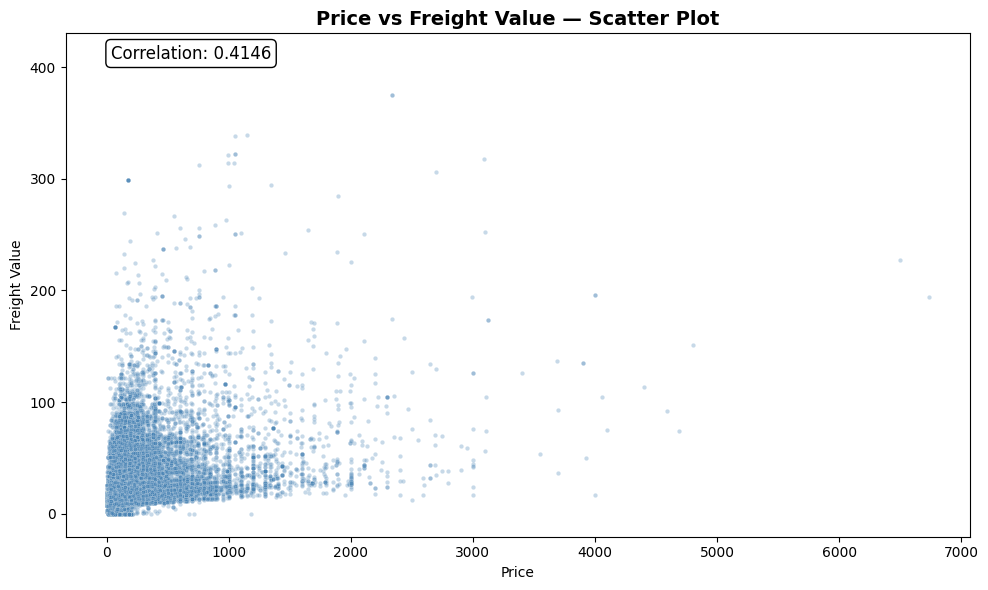

In [81]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='price',
    y='freight_value',
    data=master,
    alpha=0.3,
    color='steelblue',
    s=10
)

corr_value = master['price'].corr(master['freight_value'])
plt.text(
    0.05, 0.95,
    f'Correlation: {corr_value:.4f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.title(
    'Price vs Freight Value — Scatter Plot',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Price')
plt.ylabel('Freight Value')
plt.tight_layout()
plt.show()

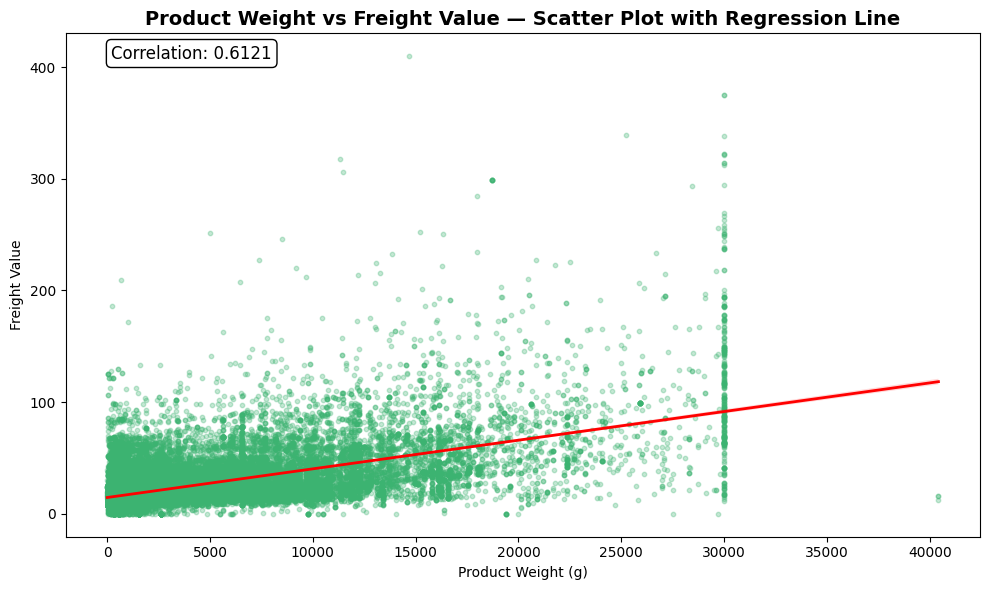

In [82]:
plt.figure(figsize=(10, 6))

sns.regplot(x='product_weight_g', y='freight_value', data=master,
            scatter_kws={'alpha': 0.3, 'color': 'mediumseagreen', 's': 10},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=95)

corr_value = master['product_weight_g'].corr(master['freight_value'])
plt.text(0.05, 0.95, f'Correlation: {corr_value:.4f}',
         transform=plt.gca().transAxes,
         fontsize=12, color='black',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))

plt.title('Product Weight vs Freight Value — Scatter Plot with Regression Line',
          fontsize=14, fontweight='bold')
plt.xlabel('Product Weight (g)')
plt.ylabel('Freight Value')
plt.tight_layout()
plt.show()

C:\Users\karan\AppData\Local\Temp\ipykernel_27960\932131404.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='payment_type', y='payment_value', data=master,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\932131404.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_payment.index, y=mean_payment.values,


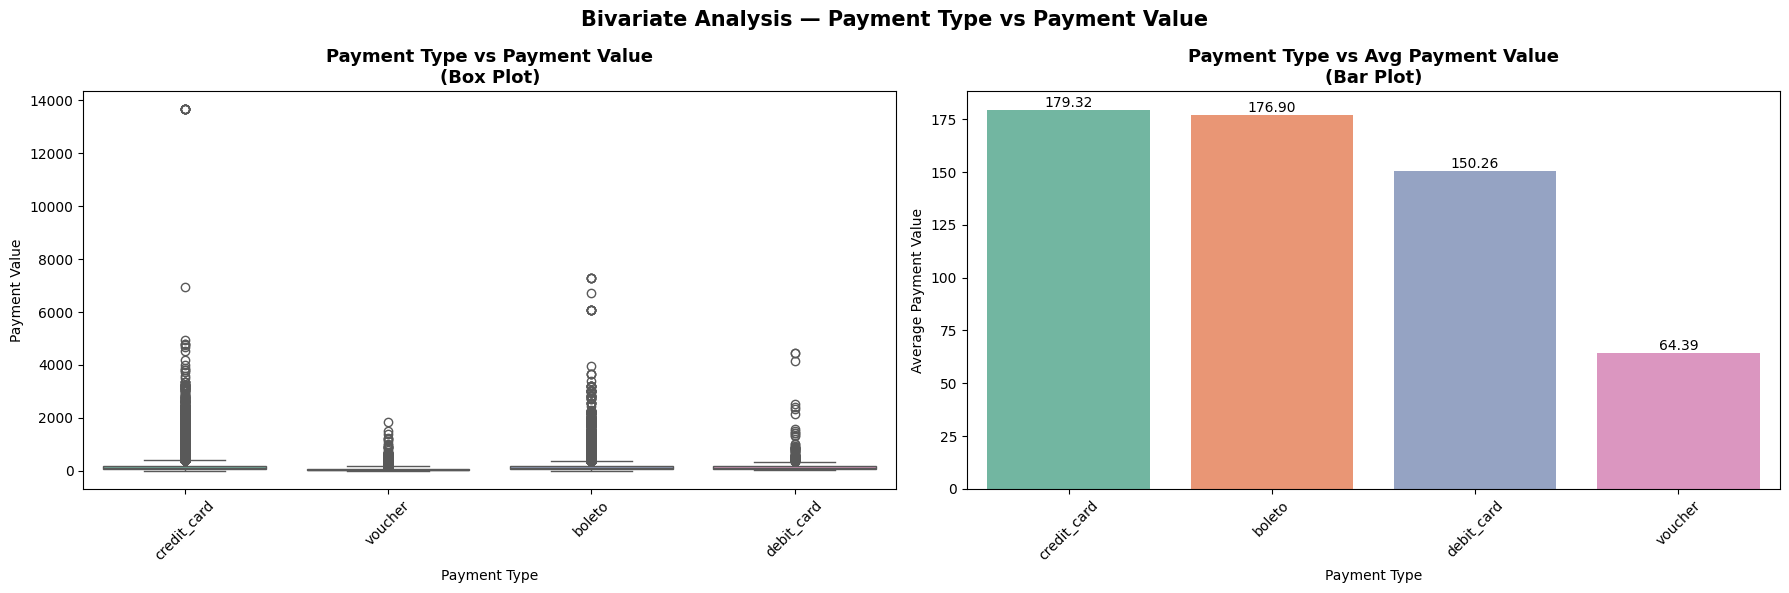

    PAYMENT TYPE vs PAYMENT VALUE — SUMMARY
                mean  median    min       max  count
payment_type                                        
boleto        176.90  105.59  11.62   7274.88  22443
credit_card   179.32  115.04   0.01  13664.08  84979
debit_card    150.26   97.55  13.38   4445.50   1657
voucher        64.39   39.75   0.00   1839.05   6140


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 1. Box Plot ───────────────────────────────────────────────────────────────
sns.boxplot(x='payment_type', y='payment_value', data=master,
            ax=axes[0], palette='Set2')
axes[0].set_title('Payment Type vs Payment Value\n(Box Plot)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Payment Value')
axes[0].tick_params(axis='x', rotation=45)

# ── 2. Bar Plot (Mean Payment Value) ─────────────────────────────────────────
mean_payment = master.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
sns.barplot(x=mean_payment.index, y=mean_payment.values,
            ax=axes[1], palette='Set2')
axes[1].set_title('Payment Type vs Avg Payment Value\n(Bar Plot)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Average Payment Value')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)



plt.suptitle('Bivariate Analysis — Payment Type vs Payment Value',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Print Summary Stats ────────────────────────────────────────────────────
print("=" * 60)
print("    PAYMENT TYPE vs PAYMENT VALUE — SUMMARY")
print("=" * 60)
print(master.groupby('payment_type')['payment_value'].agg(['mean','median','min','max','count']).round(2))

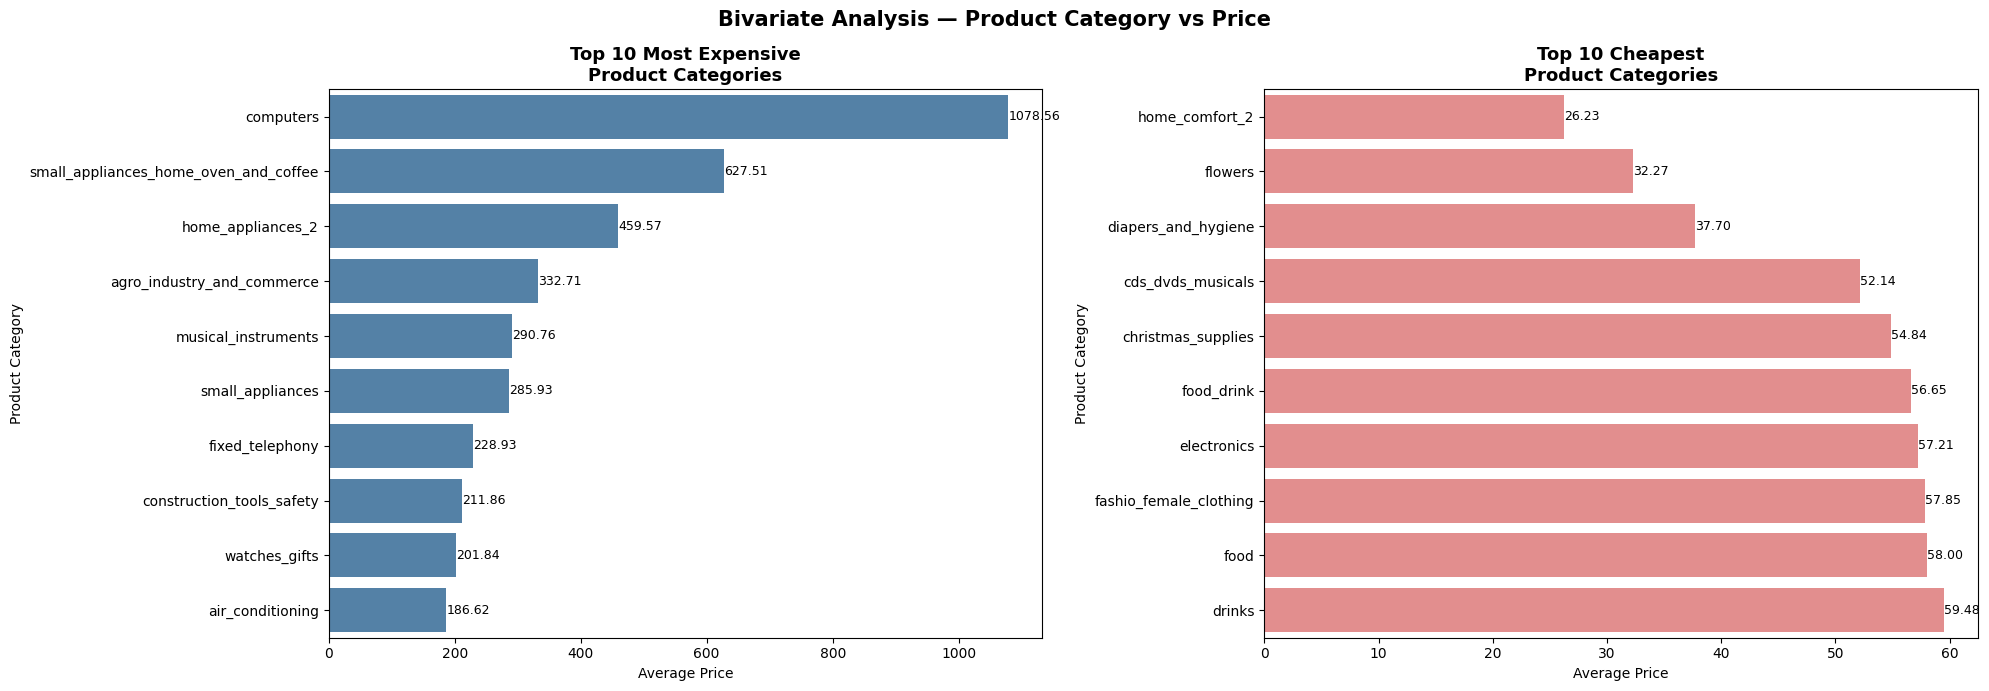

    PRODUCT CATEGORY vs PRICE — SUMMARY
                                          mean   median    min      max
product_category_name_english                                          
computers                              1078.56  1100.00  34.50  4590.00
small_appliances_home_oven_and_coffee   627.51   618.00  10.19  2899.00
home_appliances_2                       459.57   228.94  13.90  2350.00
agro_industry_and_commerce              332.71   299.95  12.99  2990.00
musical_instruments                     290.76    94.90   4.90  4399.87
small_appliances                        285.93    99.99   6.50  4799.00
fixed_telephony                         228.93    62.00   6.99  1790.00
construction_tools_safety               211.86   129.57   8.90  3099.90
watches_gifts                           201.84   129.00   8.99  3999.90
air_conditioning                        186.62   139.00  10.90  1599.00


In [89]:
top10_price = master.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(10)


bottom10_price = master.groupby('product_category_name_english')['price'].mean().sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(x=top10_price.values, y=top10_price.index,
            ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Most Expensive\nProduct Categories',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Price')
axes[0].set_ylabel('Product Category')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.2f}',
                     (p.get_width(), p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)


sns.barplot(x=bottom10_price.values, y=bottom10_price.index,
            ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 Cheapest\nProduct Categories',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Price')
axes[1].set_ylabel('Product Category')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.2f}',
                     (p.get_width(), p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)

top10_cats = master.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(10).index
filtered   = master[master['product_category_name_english'].isin(top10_cats)]



plt.suptitle('Bivariate Analysis — Product Category vs Price',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Print Summary Stats ────────────────────────────────────────────────────
print("=" * 60)
print("    PRODUCT CATEGORY vs PRICE — SUMMARY")
print("=" * 60)
print(master.groupby('product_category_name_english')['price']
      .agg(['mean','median','min','max'])
      .sort_values('mean', ascending=False)
      .head(10)
      .round(2))

    BEST RATED CATEGORIES
                                       mean  median  count
product_category_name_english                             
cds_dvds_musicals                      4.64     5.0     14
fashion_childrens_clothes              4.50     5.0      8
books_general_interest                 4.44     5.0    559
books_imported                         4.42     5.0     62
flowers                                4.42     5.0     31
costruction_tools_tools                4.42     5.0    101
books_technical                        4.39     5.0    268
food_drink                             4.32     5.0    290
small_appliances_home_oven_and_coffee  4.32     5.0     78
luggage_accessories                    4.30     5.0   1159

    WORST RATED CATEGORIES
                                   mean  median  count
product_category_name_english                         
security_and_services              2.50     2.5      2
diapers_and_hygiene                3.21     3.0     38
office_furniture  

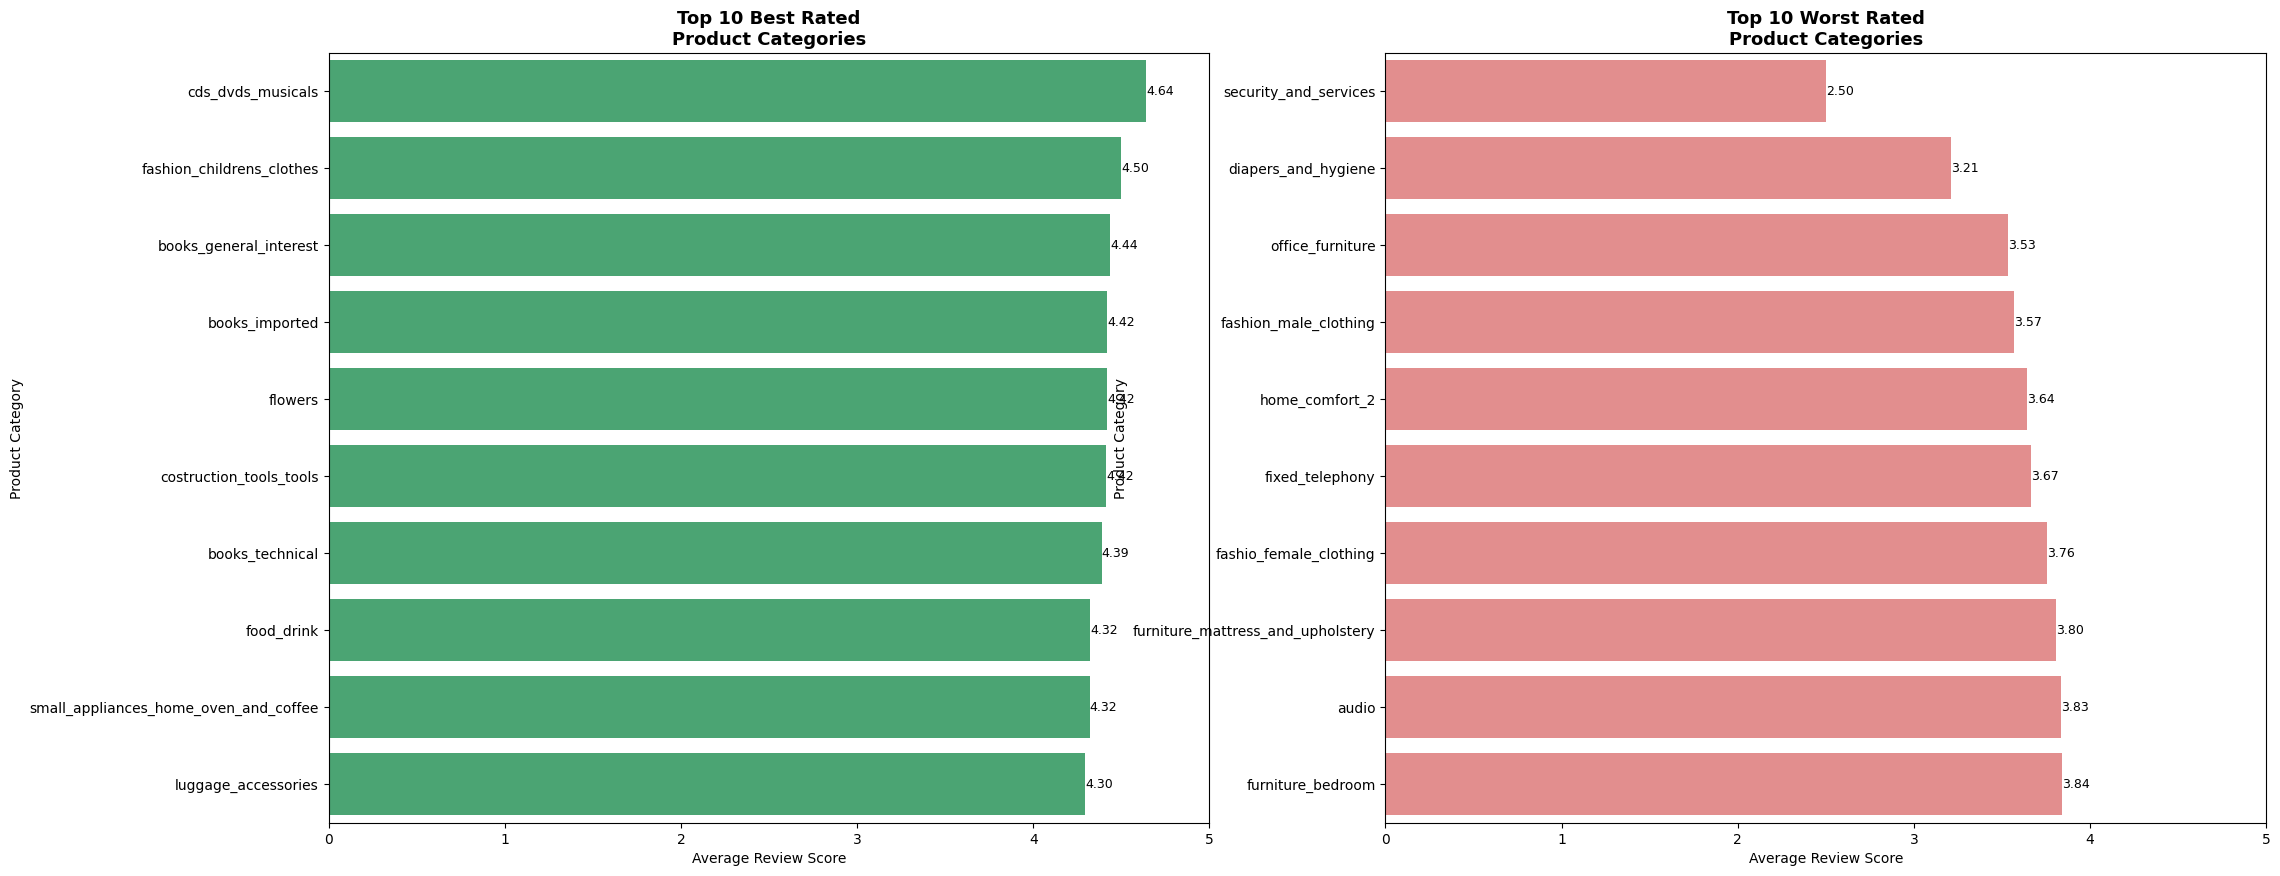

In [92]:

top10_rated = master.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)


bottom10_rated = master.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(25, 10))

# ── 3. Top 10 Bar Plot ────────────────────────────────────────────────────────
sns.barplot(x=top10_rated.values, y=top10_rated.index,
            ax=axes[0], color='mediumseagreen')
axes[0].set_title('Top 10 Best Rated\nProduct Categories',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Review Score')
axes[0].set_ylabel('Product Category')
axes[0].set_xlim(0, 5)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.2f}',
                     (p.get_width(), p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)

# ── 4. Bottom 10 Bar Plot ─────────────────────────────────────────────────────
sns.barplot(x=bottom10_rated.values, y=bottom10_rated.index,
            ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 Worst Rated\nProduct Categories',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Review Score')
axes[1].set_ylabel('Product Category')
axes[1].set_xlim(0, 5)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.2f}',
                     (p.get_width(), p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)

# ── 5. Box Plot Top 10 Worst Categories ──────────────────────────────────────
worst10_cats = master.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=True).head(10).index
filtered     = master[master['product_category_name_english'].isin(worst10_cats)]



# ── 6. Print Summary Stats ────────────────────────────────────────────────────
print("=" * 60)
print("    BEST RATED CATEGORIES")
print("=" * 60)
print(master.groupby('product_category_name_english')['review_score']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
      .head(10)
      .round(2))

print("\n" + "=" * 60)
print("    WORST RATED CATEGORIES")
print("=" * 60)
print(master.groupby('product_category_name_english')['review_score']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=True)
      .head(10)
      .round(2))

C:\Users\karan\AppData\Local\Temp\ipykernel_27960\3178481117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='order_month', y='payment_value', data=master,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\3178481117.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\3178481117.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_payment_month.index, y=mean_payment_month.values,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\3178481117.py:20: 

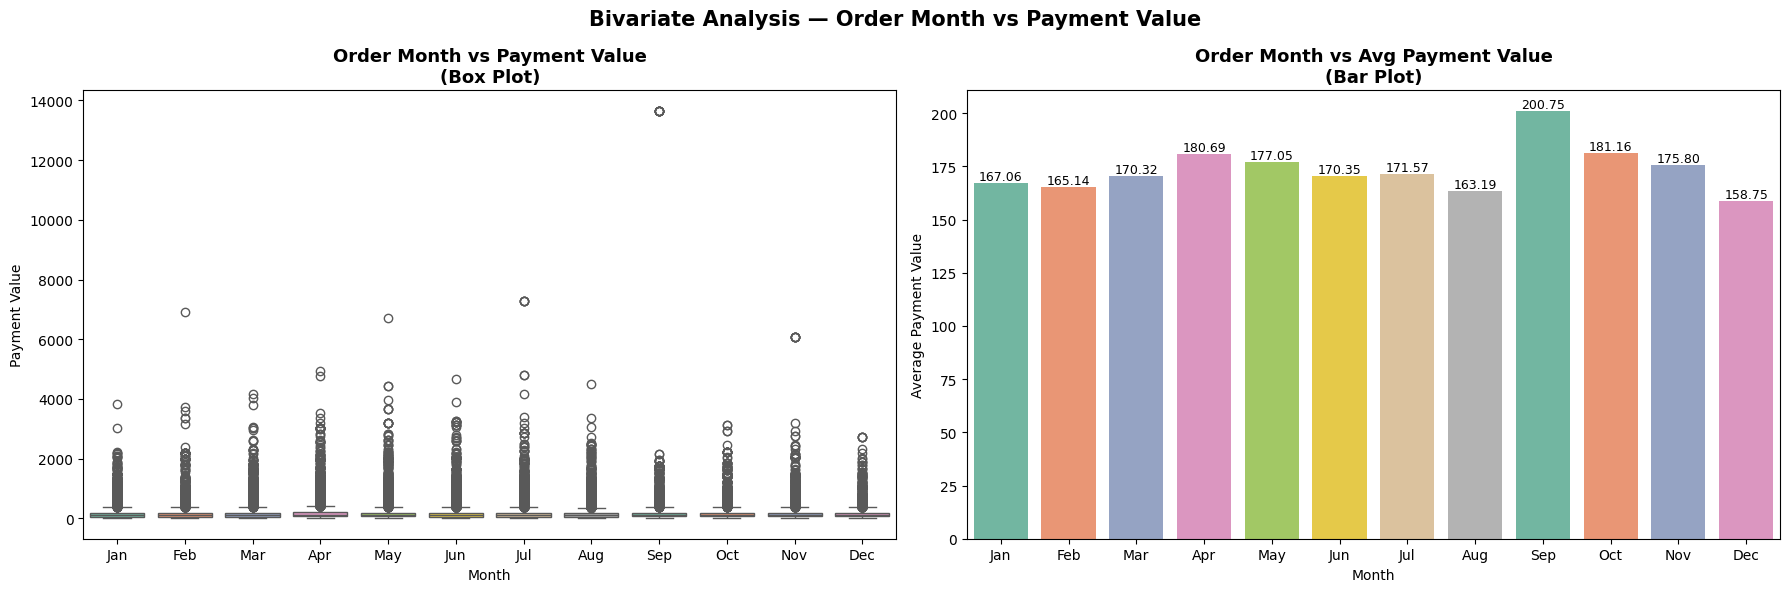

    ORDER MONTH vs PAYMENT VALUE — SUMMARY
       mean  median   min       max  count
Jan  167.06  106.97  0.00   3826.80   9301
Feb  165.14  106.87  0.23   6929.31   9816
Mar  170.32  108.00  0.13   4175.26  11489
Apr  180.69  111.55  0.00   4950.34  10883
May  177.05  110.00  0.00   6726.66  12426
Jun  170.35  108.89  0.00   4681.78  11056
Jul  171.57  107.85  0.01   7274.88  12012
Aug  163.19  104.19  0.01   4513.32  12479
Sep  200.75  106.38  0.23  13664.08   5015
Oct  181.16  108.60  0.00   3126.50   5491
Nov  175.80  110.96  0.03   6081.54   8880
Dec  158.75  106.44  0.17   2734.66   6371


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 1. Box Plot ───────────────────────────────────────────────────────────────
sns.boxplot(x='order_month', y='payment_value', data=master,
            ax=axes[0], palette='Set2')
axes[0].set_title('Order Month vs Payment Value\n(Box Plot)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Payment Value')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

# ── 2. Bar Plot (Mean Payment Value) ─────────────────────────────────────────
mean_payment_month = master.groupby('order_month')['payment_value'].mean().sort_index()
sns.barplot(x=mean_payment_month.index, y=mean_payment_month.values,
            ax=axes[1], palette='Set2')
axes[1].set_title('Order Month vs Avg Payment Value\n(Bar Plot)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Payment Value')
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Bivariate Analysis — Order Month vs Payment Value',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Print Summary Stats ────────────────────────────────────────────────────
print("=" * 60)
print("    ORDER MONTH vs PAYMENT VALUE — SUMMARY")
print("=" * 60)
summary_stats = master.groupby('order_month')['payment_value'].agg(['mean','median','min','max','count']).round(2)
summary_stats.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(summary_stats)

                                     Jan        Feb        Mar        Apr  \
product_category_name_english                                               
auto                            58649.17   72126.40   78461.60   90480.93   
bed_bath_table                 145060.80  122003.10  161783.96  160920.59   
computers_accessories          156392.45  226973.49  182883.06  116893.64   
cool_stuff                      61091.19   51410.42   70357.76   67608.01   
furniture_decor                129816.06  100228.01  167799.41  143436.07   
garden_tools                    61047.14   67657.00   88683.78   89651.11   
health_beauty                  107114.89  141233.79  145597.00  148555.40   
housewares                      66349.88   74700.04  102438.34   96088.82   
sports_leisure                 142755.60  126315.61  158909.60  132436.26   
watches_gifts                  111507.11   86912.77  139074.77  136770.72   

                                     May        Jun        Jul        Aug  

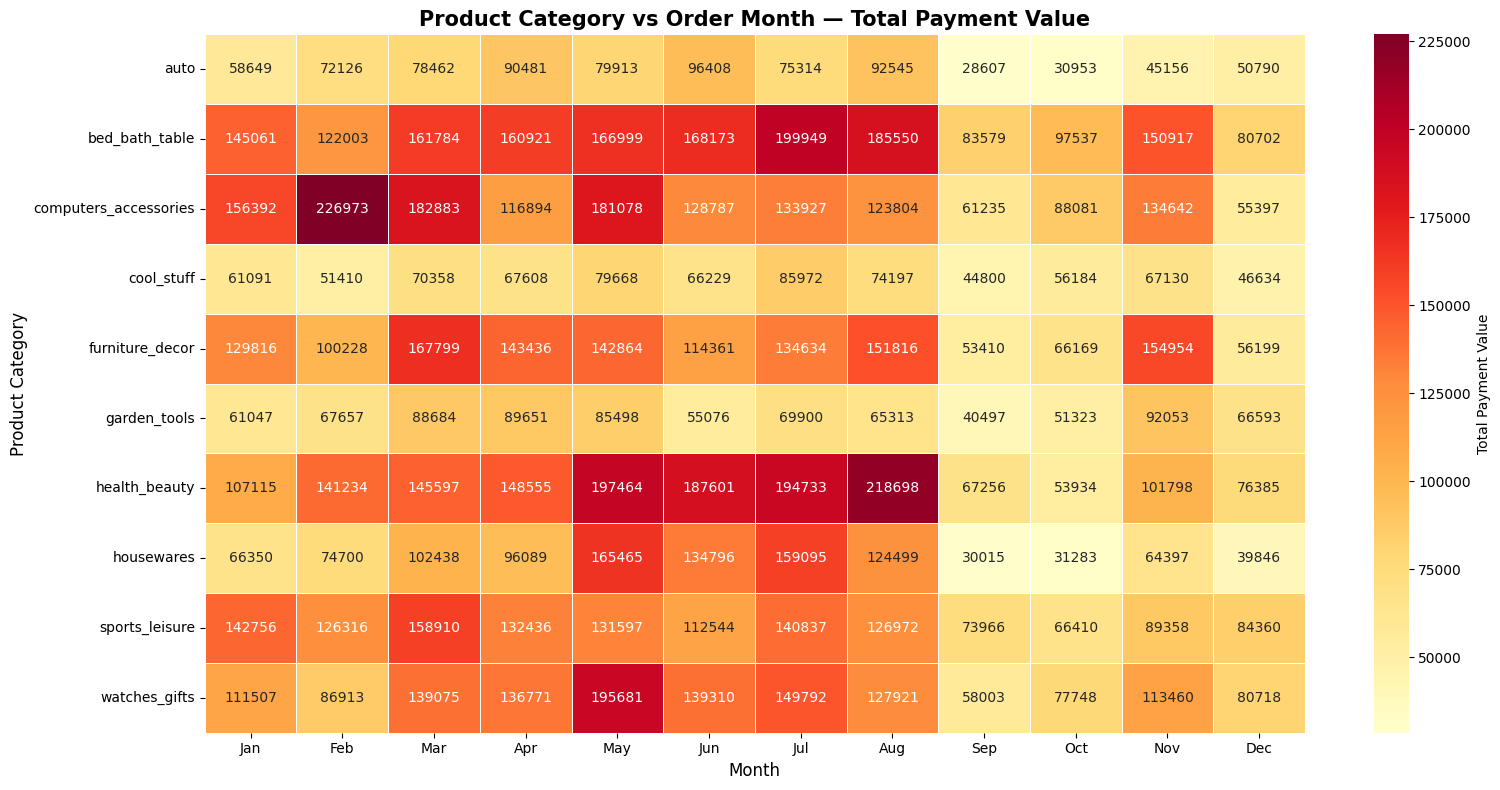

In [94]:
top10_cats = master.groupby('product_category_name_english')['payment_value']\
             .sum().sort_values(ascending=False).head(10).index

# ── 2. Filter Top 10 Categories ───────────────────────────────────────────────
filtered = master[master['product_category_name_english'].isin(top10_cats)]

# ── 3. Create Pivot Table ─────────────────────────────────────────────────────
pivot = filtered.groupby(['product_category_name_english', 'order_month'])['payment_value']\
        .sum().unstack()

# Rename columns to month names
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

print(pivot.round(2))

# ── 4. Plot Heatmap ───────────────────────────────────────────────────────────
plt.figure(figsize=(16, 8))
sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Total Payment Value'})

plt.title('Product Category vs Order Month — Total Payment Value',
          fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

    YEAR vs PAYMENT VALUE grouped by PAYMENT TYPE
   order_year payment_type  payment_value
0        2017       boleto     1890408.32
1        2017  credit_card     6816472.62
2        2017   debit_card       50476.20
3        2017      voucher      187498.94
4        2018       boleto     2079863.47
5        2018  credit_card     8421965.89
6        2018   debit_card      198512.04
7        2018      voucher      207852.14


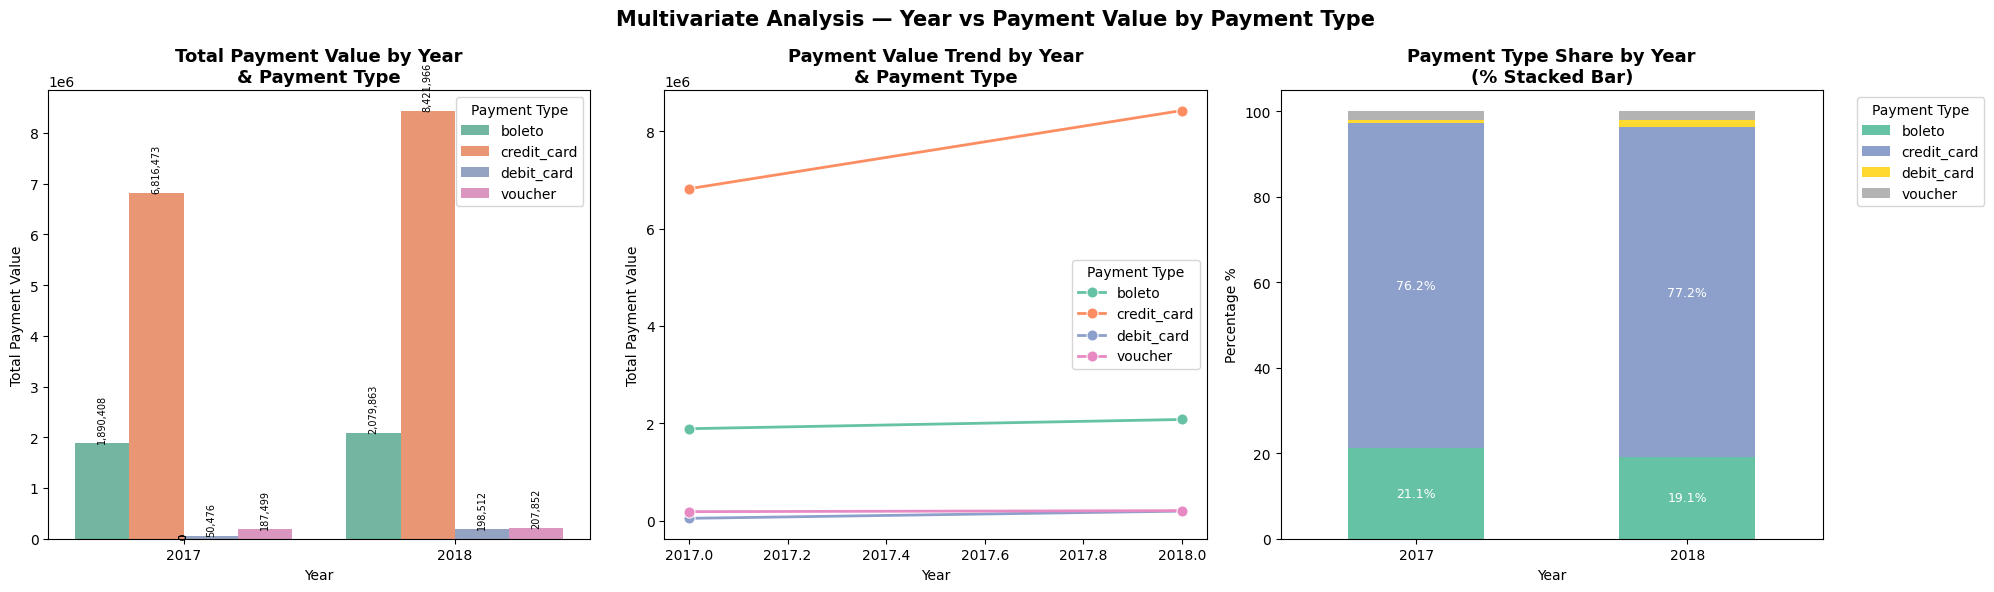

In [95]:

# ── 1. Group Data ─────────────────────────────────────────────────────────────
grouped = master.groupby(['order_year', 'payment_type'])['payment_value']\
          .sum().reset_index()

print("=" * 60)
print("    YEAR vs PAYMENT VALUE grouped by PAYMENT TYPE")
print("=" * 60)
print(grouped)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 2. Grouped Bar Chart ──────────────────────────────────────────────────────
sns.barplot(x='order_year', y='payment_value', hue='payment_type',
            data=grouped, ax=axes[0], palette='Set2')
axes[0].set_title('Total Payment Value by Year\n& Payment Type',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Payment Value')
axes[0].legend(title='Payment Type')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=7, rotation=90)

# ── 3. Line Chart ─────────────────────────────────────────────────────────────
sns.lineplot(x='order_year', y='payment_value', hue='payment_type',
             data=grouped, ax=axes[1], palette='Set2',
             marker='o', linewidth=2, markersize=8)
axes[1].set_title('Payment Value Trend by Year\n& Payment Type',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Payment Value')
axes[1].legend(title='Payment Type')

# ── 4. Percentage Stacked Bar ─────────────────────────────────────────────────
pivot = grouped.pivot(index='order_year', columns='payment_type', values='payment_value')
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=axes[2],
               colormap='Set2', width=0.5)
axes[2].set_title('Payment Type Share by Year\n(% Stacked Bar)',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Percentage %')
axes[2].legend(title='Payment Type', bbox_to_anchor=(1.05, 1))
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    height = p.get_height()
    if height > 3:
        axes[2].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2,
                          p.get_y() + height / 2),
                         ha='center', va='center', fontsize=9, color='white')

plt.suptitle('Multivariate Analysis — Year vs Payment Value by Payment Type',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

  HYPOTHESIS 3 — Delivery Delay vs Review Score

On Time Orders : 104160
Delayed Orders : 8713

On Time — Avg Review Score : 4.2114
Delayed — Avg Review Score : 2.5493
Difference                 : 1.6621

Mann Whitney U Statistic : 694792260.5000
P Value                  : 0.000000

✅ REJECT H0 — On time deliveries get significantly higher review scores

  HYPOTHESIS 6 — Installments vs Payment Value

Median Installments : 2.0

Low  Installments (≤ 2.0) — Avg Payment : ₹132.69  Count: 70822
High Installments (> 2.0) — Avg Payment : ₹235.50  Count: 44397
Difference                                   : ₹102.81

Pearson Correlation : 0.2742
P Value             : 0.000000

Mann Whitney U Statistic : 2214868822.5000
P Value                  : 0.000000

✅ REJECT H0 — Higher installments lead to significantly higher payment value


C:\Users\karan\AppData\Local\Temp\ipykernel_27960\1562541308.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_counts.index, y=delivery_counts.values,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\1562541308.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='delivery_status', y='review_score',
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\1562541308.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=install_counts.index, y=install_counts.values,
C:\Users\karan\AppData\Local\Temp\ipykernel_27960\1562541308.py:1

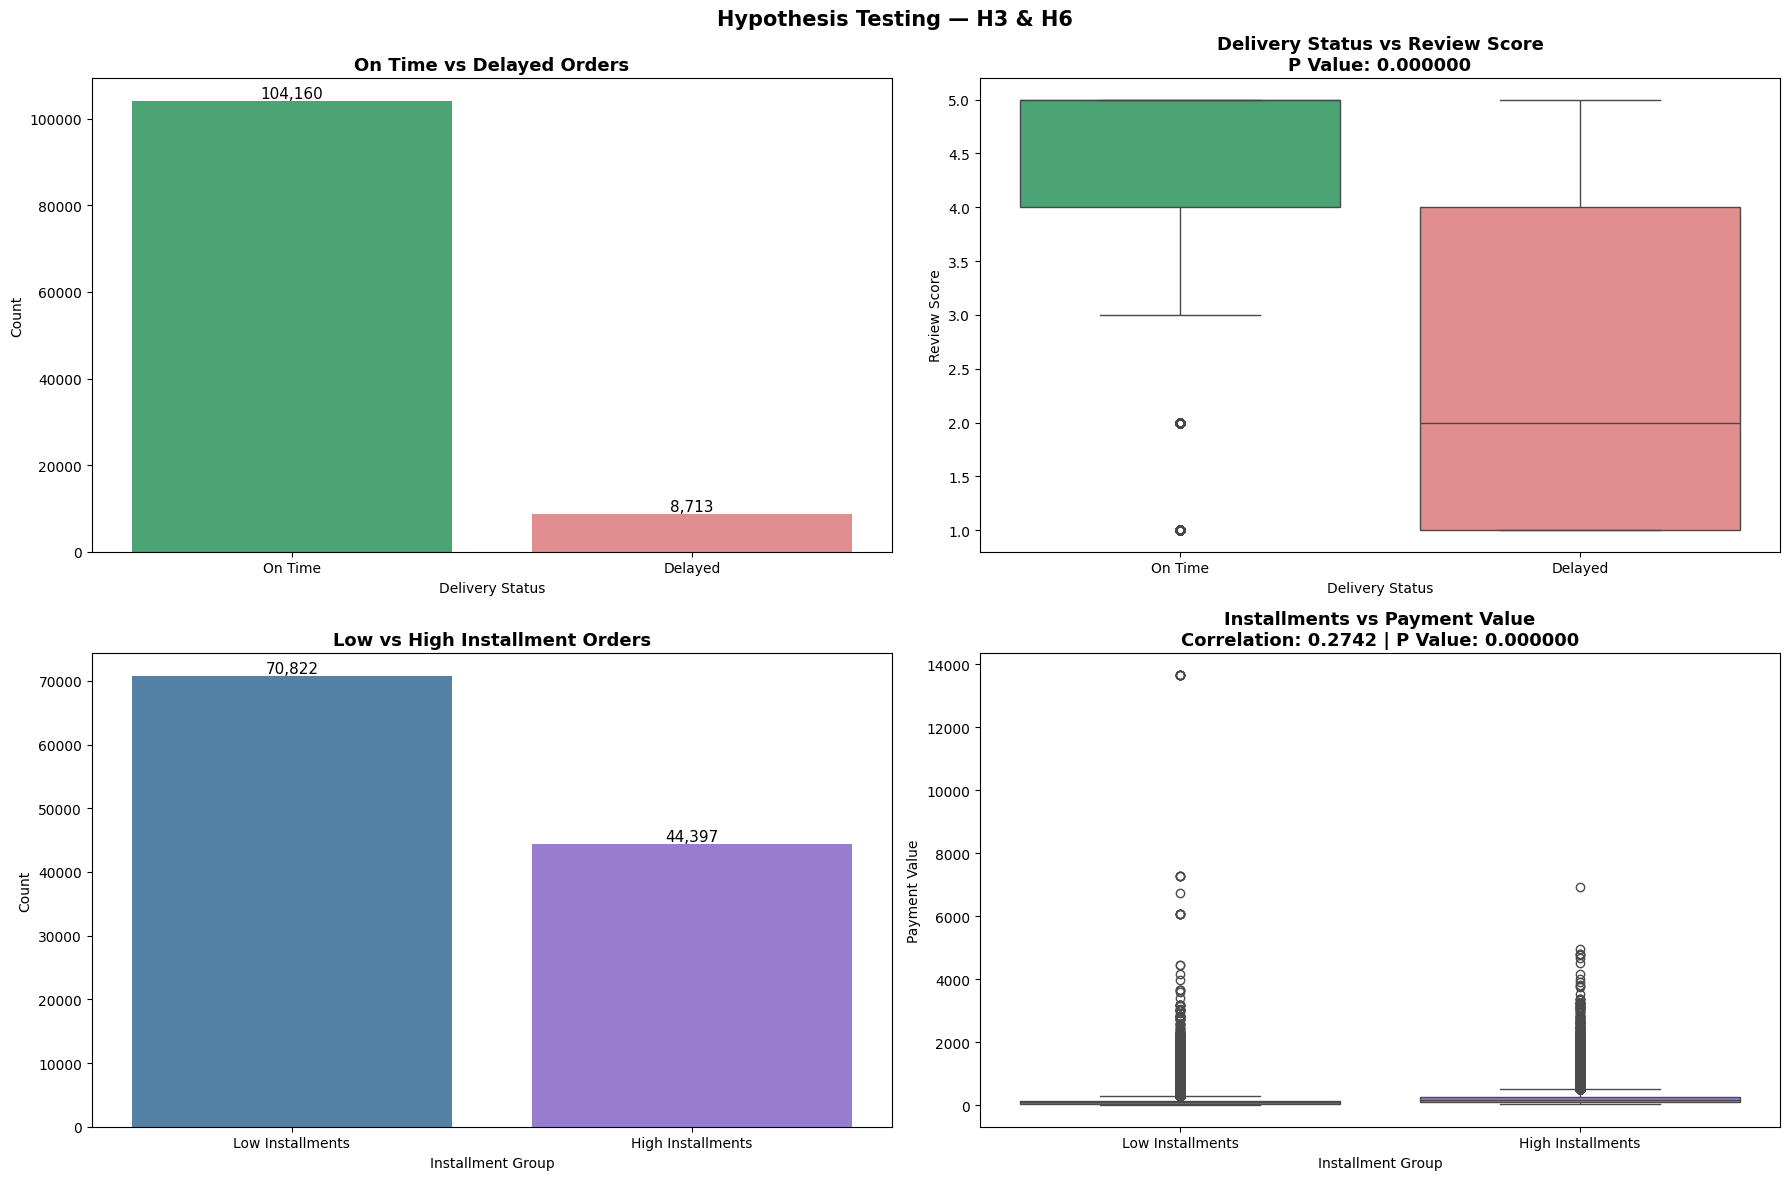

In [97]:
import scipy.stats as stats


print("=" * 60)
print("  HYPOTHESIS 3 — Delivery Delay vs Review Score")
print("=" * 60)

# ── Create Delivery Status Column ─────────────────────────
h3 = master.dropna(subset=['order_delivered_customer_date',
                             'order_estimated_delivery_date',
                             'review_score']).copy()

h3['delivery_status'] = np.where(
    h3['order_delivered_customer_date'] <= h3['order_estimated_delivery_date'],
    'On Time', 'Delayed')

# ── Count ─────────────────────────────────────────────────
print(f"\nOn Time Orders : {(h3['delivery_status'] == 'On Time').sum()}")
print(f"Delayed Orders : {(h3['delivery_status'] == 'Delayed').sum()}")

# ── Average Review Score ──────────────────────────────────
on_time = h3[h3['delivery_status'] == 'On Time']['review_score']
delayed = h3[h3['delivery_status'] == 'Delayed']['review_score']

print(f"\nOn Time — Avg Review Score : {on_time.mean():.4f}")
print(f"Delayed — Avg Review Score : {delayed.mean():.4f}")
print(f"Difference                 : {on_time.mean() - delayed.mean():.4f}")

# ── Mann Whitney U Test ───────────────────────────────────
u_stat, u_pvalue = stats.mannwhitneyu(on_time, delayed, alternative='greater')
print(f"\nMann Whitney U Statistic : {u_stat:.4f}")
print(f"P Value                  : {u_pvalue:.6f}")

if u_pvalue < 0.05:
    print("\n✅ REJECT H0 — On time deliveries get significantly higher review scores")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference in review scores")


# ═══════════════════════════════════════════════════════════
# HYPOTHESIS 6 — Installments vs Payment Value
# ═══════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  HYPOTHESIS 6 — Installments vs Payment Value")
print("=" * 60)

# ── Split into Low and High Installments ──────────────────
h6 = master.dropna(subset=['payment_installments', 'payment_value']).copy()

median_installments  = h6['payment_installments'].median()
low_installments     = h6[h6['payment_installments'] <= median_installments]['payment_value']
high_installments    = h6[h6['payment_installments'] >  median_installments]['payment_value']

print(f"\nMedian Installments : {median_installments}")
print(f"\nLow  Installments (≤ {median_installments}) — Avg Payment : ₹{low_installments.mean():.2f}  Count: {len(low_installments)}")
print(f"High Installments (> {median_installments}) — Avg Payment : ₹{high_installments.mean():.2f}  Count: {len(high_installments)}")
print(f"Difference                                   : ₹{high_installments.mean() - low_installments.mean():.2f}")

# ── Pearson Correlation ───────────────────────────────────
corr, p_value = stats.pearsonr(h6['payment_installments'], h6['payment_value'])
print(f"\nPearson Correlation : {corr:.4f}")
print(f"P Value             : {p_value:.6f}")

# ── Mann Whitney U Test ───────────────────────────────────
u_stat2, u_pvalue2 = stats.mannwhitneyu(high_installments, low_installments, alternative='greater')
print(f"\nMann Whitney U Statistic : {u_stat2:.4f}")
print(f"P Value                  : {u_pvalue2:.6f}")

if u_pvalue2 < 0.05:
    print("\n✅ REJECT H0 — Higher installments lead to significantly higher payment value")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference in payment value")


# ═══════════════════════════════════════════════════════════
# PLOTS FOR BOTH HYPOTHESES
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1 — Delivery Status Count ───────────────────────
delivery_counts = h3['delivery_status'].value_counts()
sns.barplot(x=delivery_counts.index, y=delivery_counts.values,
            ax=axes[0][0], palette=['mediumseagreen', 'lightcoral'])
axes[0][0].set_title('On Time vs Delayed Orders', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Delivery Status')
axes[0][0].set_ylabel('Count')
for p in axes[0][0].patches:
    axes[0][0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# ── Plot 2 — Delivery Status vs Review Score ──────────────
sns.boxplot(x='delivery_status', y='review_score',
            data=h3, ax=axes[0][1],
            palette=['mediumseagreen', 'lightcoral'])
axes[0][1].set_title(f'Delivery Status vs Review Score\nP Value: {u_pvalue:.6f}',
                     fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Delivery Status')
axes[0][1].set_ylabel('Review Score')

# ── Plot 3 — Installments Distribution ───────────────────
h6['installment_group'] = np.where(
    h6['payment_installments'] <= median_installments,
    'Low Installments', 'High Installments')
install_counts = h6['installment_group'].value_counts()
sns.barplot(x=install_counts.index, y=install_counts.values,
            ax=axes[1][0], palette=['steelblue', 'mediumpurple'])
axes[1][0].set_title('Low vs High Installment Orders',
                     fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Installment Group')
axes[1][0].set_ylabel('Count')
for p in axes[1][0].patches:
    axes[1][0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# ── Plot 4 — Installments vs Payment Value ────────────────
sns.boxplot(x='installment_group', y='payment_value',
            data=h6, ax=axes[1][1],
            palette=['steelblue', 'mediumpurple'])
axes[1][1].set_title(f'Installments vs Payment Value\nCorrelation: {corr:.4f} | P Value: {u_pvalue2:.6f}',
                     fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Installment Group')
axes[1][1].set_ylabel('Payment Value')

plt.suptitle('Hypothesis Testing — H3 & H6',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

     DELIVERY TIME SUMMARY
Avg Actual Delivery Days    : 11.95
Avg Estimated Delivery Days : 23.38
Avg Delay Days              : -11.42

     TOP 10 STATES WITH LONGEST DELIVERY TIME
customer_state  avg_actual_days  avg_delay_days  avg_review_score  total_orders
            RR            28.33          -16.91              3.88            43
            AP            27.62          -18.13              4.28            82
            AM            25.96          -19.20              4.11           167
            AL            23.98           -8.10              3.81           437
            PA            22.99          -13.76              3.84          1050
            MA            21.11           -9.05              3.73           800
            SE            20.70           -9.34              3.88           379
            CE            20.17          -10.68              3.89          1475
            AC            20.15          -20.64              4.11            92
            PB   

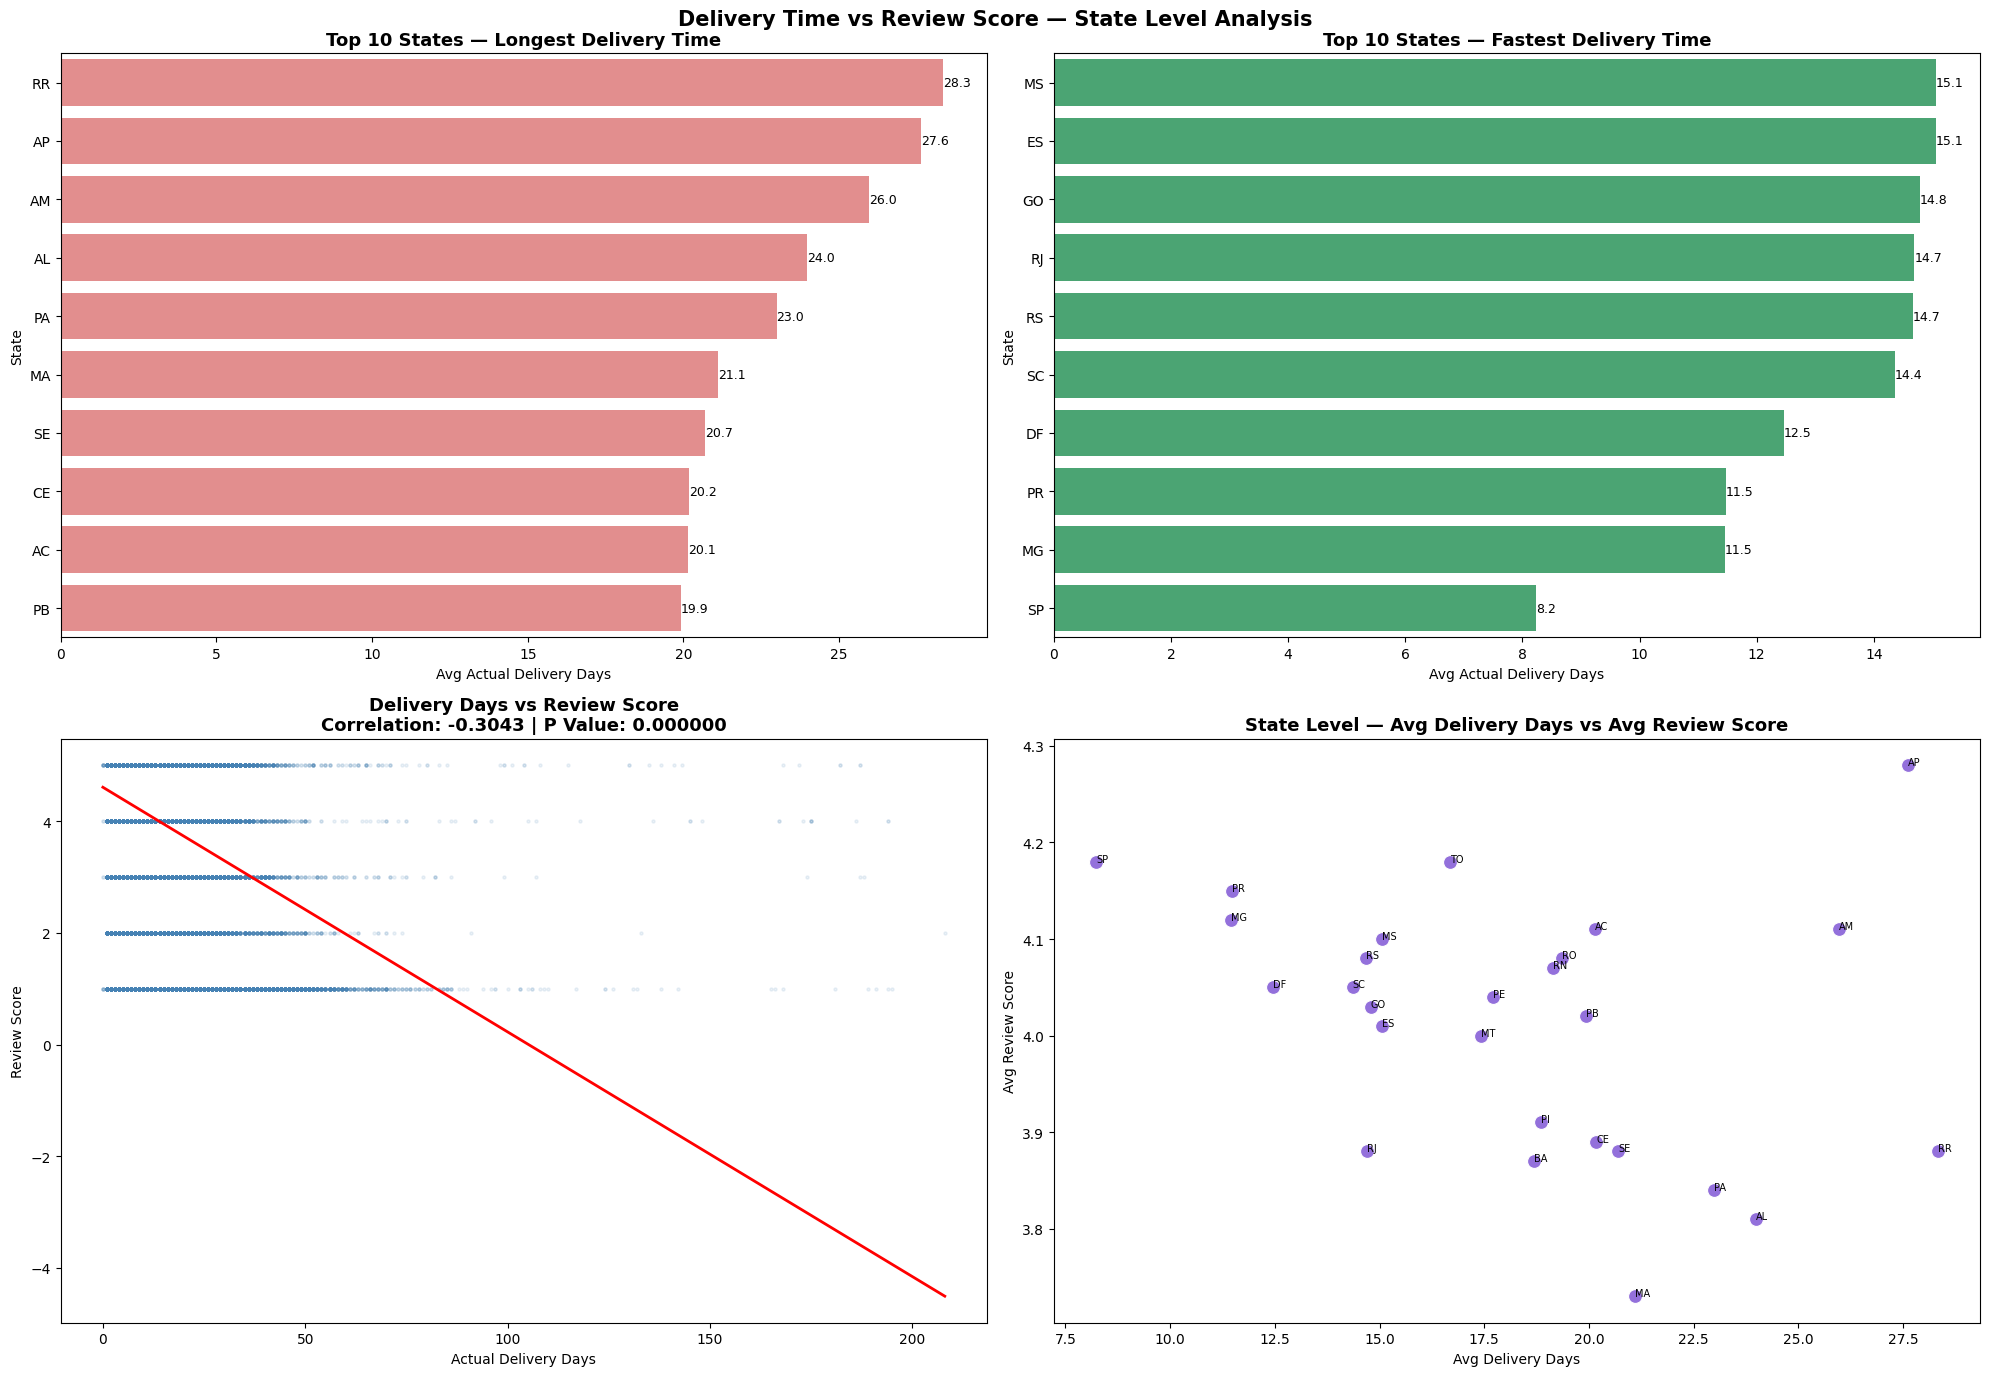

In [98]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ═══════════════════════════════════════════════════════════
# STEP 1 — Create Delivery Time Columns
# ═══════════════════════════════════════════════════════════

delivery = master.dropna(subset=['order_purchase_timestamp',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date',
                                  'review_score',
                                  'customer_state']).copy()

# Actual delivery days
delivery['actual_delivery_days'] = (
    delivery['order_delivered_customer_date'] -
    delivery['order_purchase_timestamp']).dt.days

# Estimated delivery days
delivery['estimated_delivery_days'] = (
    delivery['order_estimated_delivery_date'] -
    delivery['order_purchase_timestamp']).dt.days

# Delay days (positive = late, negative = early)
delivery['delay_days'] = (
    delivery['actual_delivery_days'] -
    delivery['estimated_delivery_days'])

print("=" * 60)
print("     DELIVERY TIME SUMMARY")
print("=" * 60)
print(f"Avg Actual Delivery Days    : {delivery['actual_delivery_days'].mean():.2f}")
print(f"Avg Estimated Delivery Days : {delivery['estimated_delivery_days'].mean():.2f}")
print(f"Avg Delay Days              : {delivery['delay_days'].mean():.2f}")


# ═══════════════════════════════════════════════════════════
# STEP 2 — State Level Analysis
# ═══════════════════════════════════════════════════════════

state_analysis = delivery.groupby('customer_state').agg(
    avg_actual_days    = ('actual_delivery_days', 'mean'),
    avg_delay_days     = ('delay_days', 'mean'),
    avg_review_score   = ('review_score', 'mean'),
    total_orders       = ('order_purchase_timestamp', 'count')
).round(2).reset_index()

state_analysis = state_analysis.sort_values('avg_actual_days', ascending=False)

print("\n" + "=" * 60)
print("     TOP 10 STATES WITH LONGEST DELIVERY TIME")
print("=" * 60)
print(state_analysis.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("     TOP 10 STATES WITH SHORTEST DELIVERY TIME")
print("=" * 60)
print(state_analysis.tail(10).to_string(index=False))


# ═══════════════════════════════════════════════════════════
# STEP 3 — Correlation — Delivery Days vs Review Score
# ═══════════════════════════════════════════════════════════

corr, p_value = stats.pearsonr(delivery['actual_delivery_days'],
                                delivery['review_score'])
print("\n" + "=" * 60)
print("     CORRELATION — DELIVERY DAYS vs REVIEW SCORE")
print("=" * 60)
print(f"Pearson Correlation : {corr:.4f}")
print(f"P Value             : {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ REJECT H0 — Delivery time significantly impacts review score")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant impact")


# ═══════════════════════════════════════════════════════════
# STEP 4 — Kruskal Wallis Test Across States
# ═══════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("     KRUSKAL WALLIS TEST — DELIVERY TIME ACROSS STATES")
print("=" * 60)

state_groups = [group['actual_delivery_days'].values
                for _, group in delivery.groupby('customer_state')]

kruskal_stat, kruskal_p = stats.kruskal(*state_groups)
print(f"Kruskal Wallis Statistic : {kruskal_stat:.4f}")
print(f"P Value                  : {kruskal_p:.6f}")

if kruskal_p < 0.05:
    print("\n✅ REJECT H0 — Delivery time varies significantly across states")
else:
    print("\n❌ FAIL TO REJECT H0 — No significant difference across states")


# ═══════════════════════════════════════════════════════════
# STEP 5 — Plots
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── Plot 1 — Top 10 vs Bottom 10 States Delivery Time ────
top10    = state_analysis.head(10)
bottom10 = state_analysis.tail(10)

sns.barplot(x='avg_actual_days', y='customer_state',
            data=top10, ax=axes[0][0], color='lightcoral')
axes[0][0].set_title('Top 10 States — Longest Delivery Time',
                     fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Avg Actual Delivery Days')
axes[0][0].set_ylabel('State')
for p in axes[0][0].patches:
    axes[0][0].annotate(f'{p.get_width():.1f}',
                        (p.get_width(), p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=9)

sns.barplot(x='avg_actual_days', y='customer_state',
            data=bottom10, ax=axes[0][1], color='mediumseagreen')
axes[0][1].set_title('Top 10 States — Fastest Delivery Time',
                     fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Avg Actual Delivery Days')
axes[0][1].set_ylabel('State')
for p in axes[0][1].patches:
    axes[0][1].annotate(f'{p.get_width():.1f}',
                        (p.get_width(), p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=9)

# ── Plot 2 — Delivery Days vs Review Score Scatter ───────
axes[1][0].scatter(delivery['actual_delivery_days'],
                   delivery['review_score'],
                   alpha=0.1, color='steelblue', s=5)
z = np.polyfit(delivery['actual_delivery_days'],
               delivery['review_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(delivery['actual_delivery_days'].min(),
                     delivery['actual_delivery_days'].max(), 100)
axes[1][0].plot(x_line, p(x_line), 'r-', linewidth=2)
axes[1][0].set_title(f'Delivery Days vs Review Score\nCorrelation: {corr:.4f} | P Value: {p_value:.6f}',
                     fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Actual Delivery Days')
axes[1][0].set_ylabel('Review Score')

# ── Plot 3 — State Review Score vs Delivery Days ─────────
sns.scatterplot(x='avg_actual_days', y='avg_review_score',
                data=state_analysis, ax=axes[1][1],
                color='mediumpurple', s=100)
for _, row in state_analysis.iterrows():
    axes[1][1].annotate(row['customer_state'],
                        (row['avg_actual_days'], row['avg_review_score']),
                        fontsize=7, ha='left')
axes[1][1].set_title('State Level — Avg Delivery Days vs Avg Review Score',
                     fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Avg Delivery Days')
axes[1][1].set_ylabel('Avg Review Score')

plt.suptitle('Delivery Time vs Review Score — State Level Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()